# Lorenz63 grid images

This notebook is split from `L63_results.ipynb` and only renders the posterior/grid image panels. It preserves the original output directory: `save/figures/lorenz63_multi_obs_notebook`.


In [1]:
# Path bootstrap: if running from ./test_notebooks, move to project root
from pathlib import Path
import os

cwd = Path.cwd().resolve()
if cwd.name == 'test_notebooks':
    os.chdir(cwd.parent)
    cwd = Path.cwd().resolve()

print('Current working directory:', cwd)


Current working directory: /home/bhchen/LearnKalmanGain


In [2]:
import os
import re
import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# torch is required to read output_records_*.pt
import torch


In [3]:
# Ensure cwd is project root (where ./save exists)
cwd = Path.cwd().resolve()
if not (cwd / 'save').exists() and (cwd.parent / 'save').exists():
    os.chdir(cwd.parent)

PROJECT_ROOT = Path.cwd().resolve()
SAVE_DIR = PROJECT_ROOT / 'save'
print('PROJECT_ROOT =', PROJECT_ROOT)
print('SAVE_DIR exists =', SAVE_DIR.exists())


PROJECT_ROOT = /home/bhchen/LearnKalmanGain
SAVE_DIR exists = True


In [4]:
# =========================
# User config for grid images
# =========================
DATASET = 'lorenz63'
OBS_FN = 'square'  # default obs_fn for diagnostics printed below
ALL_OBS_FNS = ['identity', 'square', 'arctan']
GRID_OBS_FN_DISPLAY = ['square', 'arctan', 'identity']
OBS_FN_SIGMA_Y = {
    'identity': 2.0,
    'square': 16.97,
    'arctan': 0.32,
}
SIGMA_Y = OBS_FN_SIGMA_Y[OBS_FN]

SEED = 42
PF_N = 1000000
TEST_LEN = 500

STEP_LIST = [200, 300, 400]

# Display control: currently do not show PCA12 in the main grid.
SHOW_PCA12 = False
BASE_VIEWS = ['12', '13', '23']
PCA_GRID_VIEWS = ['PCA12']
VIEWS = BASE_VIEWS + (['PCA12'] if SHOW_PCA12 else [])
VIEW_ALIASES = {
    '12': ['12', 'xy'],
    '13': ['13', 'xz'],
    '23': ['23', 'yz'],
    'PCA12': ['PCA12'],
}

# Image crop ratios (for every displayed panel)
# Left/bottom crop 10%, right/top crop 5%.
CROP_LEFT_PCT = 0.10
CROP_BOTTOM_PCT = 0.10
CROP_RIGHT_PCT = 0.05
CROP_TOP_PCT = 0.05

AXIS_LABEL_FONTSIZE = 24
TICK_FONTSIZE = 20

# Grid text/size controls
GRID_COL_TITLE_FONTSIZE = AXIS_LABEL_FONTSIZE
GRID_ROW_LABEL_FONTSIZE = AXIS_LABEL_FONTSIZE
GRID_COL_TITLE_WRAP = 20
GRID_COL_WIDTH = 3.7
GRID_ROW_HEIGHT = 3.4

# Each main non-PCA grid is expected to contain 3 views x 8 columns = 24 panels.
EXPECTED_GRID_PANEL_COUNT = 24
PANEL_PDF_DPI = 300
RENDER_PCA_GRIDS = True

N_LIST = [100]  # each method occupies one row per N

USE_POST = True
USE_ADAPTIVE = True
KIND = 'post' if USE_POST else 'prior'
RANGE_MODE = 'adaptive' if USE_ADAPTIVE else 'fixed'

RESULTS_ROOT = SAVE_DIR / f'{DATASET}_results'
GRID_FIG_SAVE_DIR = SAVE_DIR / 'figures' / f'{DATASET}_multi_obs_notebook'
GRID_FIG_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print('RESULTS_ROOT =', RESULTS_ROOT)
print('GRID_FIG_SAVE_DIR =', GRID_FIG_SAVE_DIR)
print('GRID_OBS_FN_DISPLAY =', GRID_OBS_FN_DISPLAY)


RESULTS_ROOT = /home/bhchen/LearnKalmanGain/save/lorenz63_results
GRID_FIG_SAVE_DIR = /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook
GRID_OBS_FN_DISPLAY = ['square', 'arctan', 'identity']


In [5]:
def safe_torch_load(path):
    path = str(path)
    try:
        return torch.load(path, map_location='cpu', weights_only=False)
    except TypeError:
        return torch.load(path, map_location='cpu')


def save_figure_png_pdf(fig, png_path, **savefig_kwargs):
    png_path = Path(png_path)
    pdf_path = png_path.with_suffix('.pdf')
    fig.savefig(png_path, **savefig_kwargs)
    fig.savefig(pdf_path, **savefig_kwargs)
    print('Saved:', png_path)
    print('Saved:', pdf_path)
    return png_path, pdf_path


def _score_path(path, preferred_tokens=None):
    preferred_tokens = preferred_tokens or []
    s = 0
    p = str(path)
    for tok in preferred_tokens:
        if tok in p:
            s += 10
    return s


def pick_best_path(paths, preferred_tokens=None):
    paths = list(paths)
    if not paths:
        return None
    scored = sorted(paths, key=lambda p: _score_path(p, preferred_tokens), reverse=True)
    return Path(scored[0])


def get_pf_vis_dir(obs_fn: str) -> Path:
    candidates = []
    if obs_fn == 'identity':
        candidates.extend([
            SAVE_DIR / f'{DATASET}_pf_vis_identity',
            SAVE_DIR / f'{DATASET}_pf_vis',
        ])
    else:
        candidates.append(SAVE_DIR / f'{DATASET}_pf_vis_{obs_fn}')
    candidates.append(SAVE_DIR / f'{DATASET}_pf_vis')

    for cand in candidates:
        if cand.exists():
            return cand
    return candidates[0]


BENCHMARK_METHOD_ORDER = {
    'ESRF': 0,
    'EnKF': 1,
    'iEnKS-PertObs': 2,
}
BENCHMARK_METHOD_LABELS = {
    'iEnKS-PertObs': 'IEnKF',
}


def discover_benchmark_dirs(obs_fn: str):
    sigma_y = OBS_FN_SIGMA_Y[obs_fn]
    benchmark_root = SAVE_DIR / f'benchmark_{DATASET}'
    benchmark_glob = str(benchmark_root / f'benchmark_{DATASET}_{sigma_y}_*')
    dirs = [Path(p) for p in glob.glob(benchmark_glob) if Path(p).is_dir()]
    out = []
    prefix = f'benchmark_{DATASET}_{sigma_y}_'
    for d in dirs:
        name = d.name
        method = name.replace(prefix, '') if name.startswith(prefix) else name
        if method not in BENCHMARK_METHOD_ORDER:
            continue
        out.append({
            'label': BENCHMARK_METHOD_LABELS.get(method, method),
            'dir': d,
            'kind': 'classic',
            'method': method,
            'obs_fn': obs_fn,
        })

    out.sort(key=lambda spec: (BENCHMARK_METHOD_ORDER[spec['method']], spec['dir'].name))
    return out


def _has_any_output_records(folder):
    return any(folder.glob('output_records_*.pt'))


TRAINING_MODEL_ORDER = {'ES': 0, 'NL2': 1}
TRAINING_LOSS_ORDER = {'EtE-LRes': 0, 'CorrTerms': 1}


def format_training_label(model: str, loss: str) -> str:
    if loss == 'EtE-LRes':
        return f'EtE + {model}'
    return f'{loss}+{model}'


def parse_training_folder(folder_name: str):
    m = re.search(r'_(?P<model>es|nl2)_joint_(?P<loss>[^_/]+)None_(?P<obs_fn>.+)$', folder_name)
    if not m:
        return None
    return {
        'model': m.group('model').upper(),
        'loss': m.group('loss').replace('None', '').strip('_'),
        'obs_fn': m.group('obs_fn'),
    }


def discover_training_dirs(obs_fn: str, root: Path = RESULTS_ROOT):
    if (not root.exists()) or (not root.is_dir()):
        return []

    specs = []
    for d in sorted(root.iterdir()):
        if (not d.is_dir()) or (not _has_any_output_records(d)):
            continue
        meta = parse_training_folder(d.name)
        if meta is None or meta['obs_fn'] != obs_fn:
            continue
        if meta['model'] not in TRAINING_MODEL_ORDER or meta['loss'] not in TRAINING_LOSS_ORDER:
            continue
        specs.append({
            'label': format_training_label(meta['model'], meta['loss']),
            'dir': d,
            'kind': 'train',
            'model': meta['model'],
            'loss': meta['loss'],
            'obs_fn': obs_fn,
        })

    specs.sort(
        key=lambda spec: (
            TRAINING_MODEL_ORDER[spec['model']],
            TRAINING_LOSS_ORDER[spec['loss']],
            spec['dir'].name,
        )
    )
    return specs


def build_obs_fn_bundle(obs_fn: str):
    return {
        'obs_fn': obs_fn,
        'sigma_y': OBS_FN_SIGMA_Y[obs_fn],
        'pf_dir': get_pf_vis_dir(obs_fn),
        'benchmark_specs': discover_benchmark_dirs(obs_fn),
        'training_specs': discover_training_dirs(obs_fn, RESULTS_ROOT),
        'training_root': RESULTS_ROOT,
    }


def metric_from_record(record_dict, key_candidates):
    candidate_bases = [
        record_dict.get('nn', {}),
        record_dict.get('test_results', {}),
        record_dict,
    ]
    for base in candidate_bases:
        if not isinstance(base, dict):
            continue
        for k in key_candidates:
            if k in base and base[k] is not None:
                try:
                    return float(base[k])
                except Exception:
                    continue
    return np.nan


In [6]:
def crop_image(
    img,
    left_pct=0.10,
    right_pct=0.05,
    top_pct=0.05,
    bottom_pct=0.10,
):
    # Crop image by percentages from each side.
    if img is None or getattr(img, 'ndim', 0) < 2:
        return img

    h, w = img.shape[:2]
    x0 = int(round(w * float(left_pct)))
    x1 = w - int(round(w * float(right_pct)))
    y0 = int(round(h * float(top_pct)))
    y1 = h - int(round(h * float(bottom_pct)))

    x0 = max(0, min(x0, w - 1))
    x1 = max(x0 + 1, min(x1, w))
    y0 = max(0, min(y0, h - 1))
    y1 = max(y0 + 1, min(y1, h))

    return img[y0:y1, x0:x1, ...]


def find_pf_image(step: int, view: str, pf_vis_dir=None, kind=None, range_mode=None):
    pf_vis_dir = Path(pf_vis_dir or PF_VIS_DIR)
    kind = kind or KIND
    range_mode = range_mode or RANGE_MODE
    aliases = VIEW_ALIASES[view]
    candidates = []
    for v in aliases:
        candidates.extend(glob.glob(str(pf_vis_dir / f'*timestep{step}_*_{kind}_{range_mode}_{v}.png')))
        other_mode = 'fixed' if range_mode == 'adaptive' else 'adaptive'
        candidates.extend(glob.glob(str(pf_vis_dir / f'*timestep{step}_*_{kind}_{other_mode}_{v}.png')))

    preferred = [f'pfN{PF_N}', f'_{SEED}_', f'_{kind}_{range_mode}_']
    return pick_best_path(candidates, preferred_tokens=preferred)


def find_method_image(method_dir: Path, N: int, step: int, view: str, kind=None, range_mode=None):
    kind = kind or KIND
    range_mode = range_mode or RANGE_MODE
    aliases = VIEW_ALIASES[view]
    patterns = []
    for v in aliases:
        patterns.append(f'test_{N}_0_classic_g0_step{step}_0_{kind}_{range_mode}_{v}.png')
        patterns.append(f'test_{N}_0_g0_step{step}_0_{kind}_{range_mode}_{v}.png')
        patterns.append(f'test_{N}_0*step{step}_0_{kind}_{range_mode}_{v}.png')

    candidates = []
    for pat in patterns:
        candidates.extend(glob.glob(str(method_dir / pat)))

    preferred = [f'test_{N}_0', f'step{step}_0', f'_{kind}_{range_mode}_']
    return pick_best_path(candidates, preferred_tokens=preferred)


In [7]:
obs_fn_bundles = {obs_fn: build_obs_fn_bundle(obs_fn) for obs_fn in ALL_OBS_FNS}

default_bundle = obs_fn_bundles[OBS_FN]
PF_VIS_DIR = default_bundle['pf_dir']
benchmark_specs = default_bundle['benchmark_specs']
training_specs = default_bundle['training_specs']
training_root_used = default_bundle['training_root']

print(f'[default={OBS_FN}] PF_VIS_DIR:', PF_VIS_DIR)
print(f'[default={OBS_FN}] Training root used:', training_root_used)
print(f'[default={OBS_FN}] Benchmark dirs found:', len(benchmark_specs))
for s in benchmark_specs:
    print('  -', s['label'], '|', s['dir'])
print(f'[default={OBS_FN}] Training dirs found:', len(training_specs))
for s in training_specs:
    print('  -', s['label'], '|', s['dir'])

for obs_fn in ALL_OBS_FNS:
    bundle = obs_fn_bundles[obs_fn]
    print('==================================================')
    print(f'obs_fn={obs_fn} | sigma_y={bundle["sigma_y"]}')
    print('PF_VIS_DIR:', bundle['pf_dir'])
    print('Benchmark dirs found:', len(bundle['benchmark_specs']))
    for s in bundle['benchmark_specs']:
        print('  -', s['label'], '|', s['dir'])
    print('Training root used:', bundle['training_root'])
    print('Training dirs found:', len(bundle['training_specs']))
    for s in bundle['training_specs']:
        print('  -', s['label'], '|', s['dir'])


[default=square] PF_VIS_DIR: /home/bhchen/LearnKalmanGain/save/lorenz63_pf_vis_square
[default=square] Training root used: /home/bhchen/LearnKalmanGain/save/lorenz63_results
[default=square] Benchmark dirs found: 3
  - ESRF | /home/bhchen/LearnKalmanGain/save/benchmark_lorenz63/benchmark_lorenz63_16.97_ESRF
  - EnKF | /home/bhchen/LearnKalmanGain/save/benchmark_lorenz63/benchmark_lorenz63_16.97_EnKF
  - IEnKF | /home/bhchen/LearnKalmanGain/save/benchmark_lorenz63/benchmark_lorenz63_16.97_iEnKS-PertObs
[default=square] Training dirs found: 4
  - EtE + ES | /home/bhchen/LearnKalmanGain/save/lorenz63_results/2026-02-22_20-23lorenz63_16.97_10_60_8192_es_joint_EtE-LResNone_square
  - CorrTerms+ES | /home/bhchen/LearnKalmanGain/save/lorenz63_results/2026-02-22_20-24lorenz63_16.97_10_60_8192_es_joint_CorrTermsNone_square
  - EtE + NL2 | /home/bhchen/LearnKalmanGain/save/lorenz63_results/2026-02-22_20-23lorenz63_16.97_10_60_8192_nl2_joint_EtE-LResNone_square
  - CorrTerms+NL2 | /home/bhchen/Le

## Posterior grid panels

The cell below renders all obs functions in `GRID_OBS_FN_DISPLAY` for all steps in `STEP_LIST`. Each saved main grid exports exactly 24 cropped high-resolution panel PDFs into its matching subfolder. PCA grids are rendered with the available PCA12 projection only and export one cropped PDF per PCA12 panel.


Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step200_post_adaptive_transposed.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step200_post_adaptive_transposed.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step200_post_adaptive_transposed_legend.pdf
Saved 24 cropped high-resolution panel PDFs to: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step200_post_adaptive_transposed


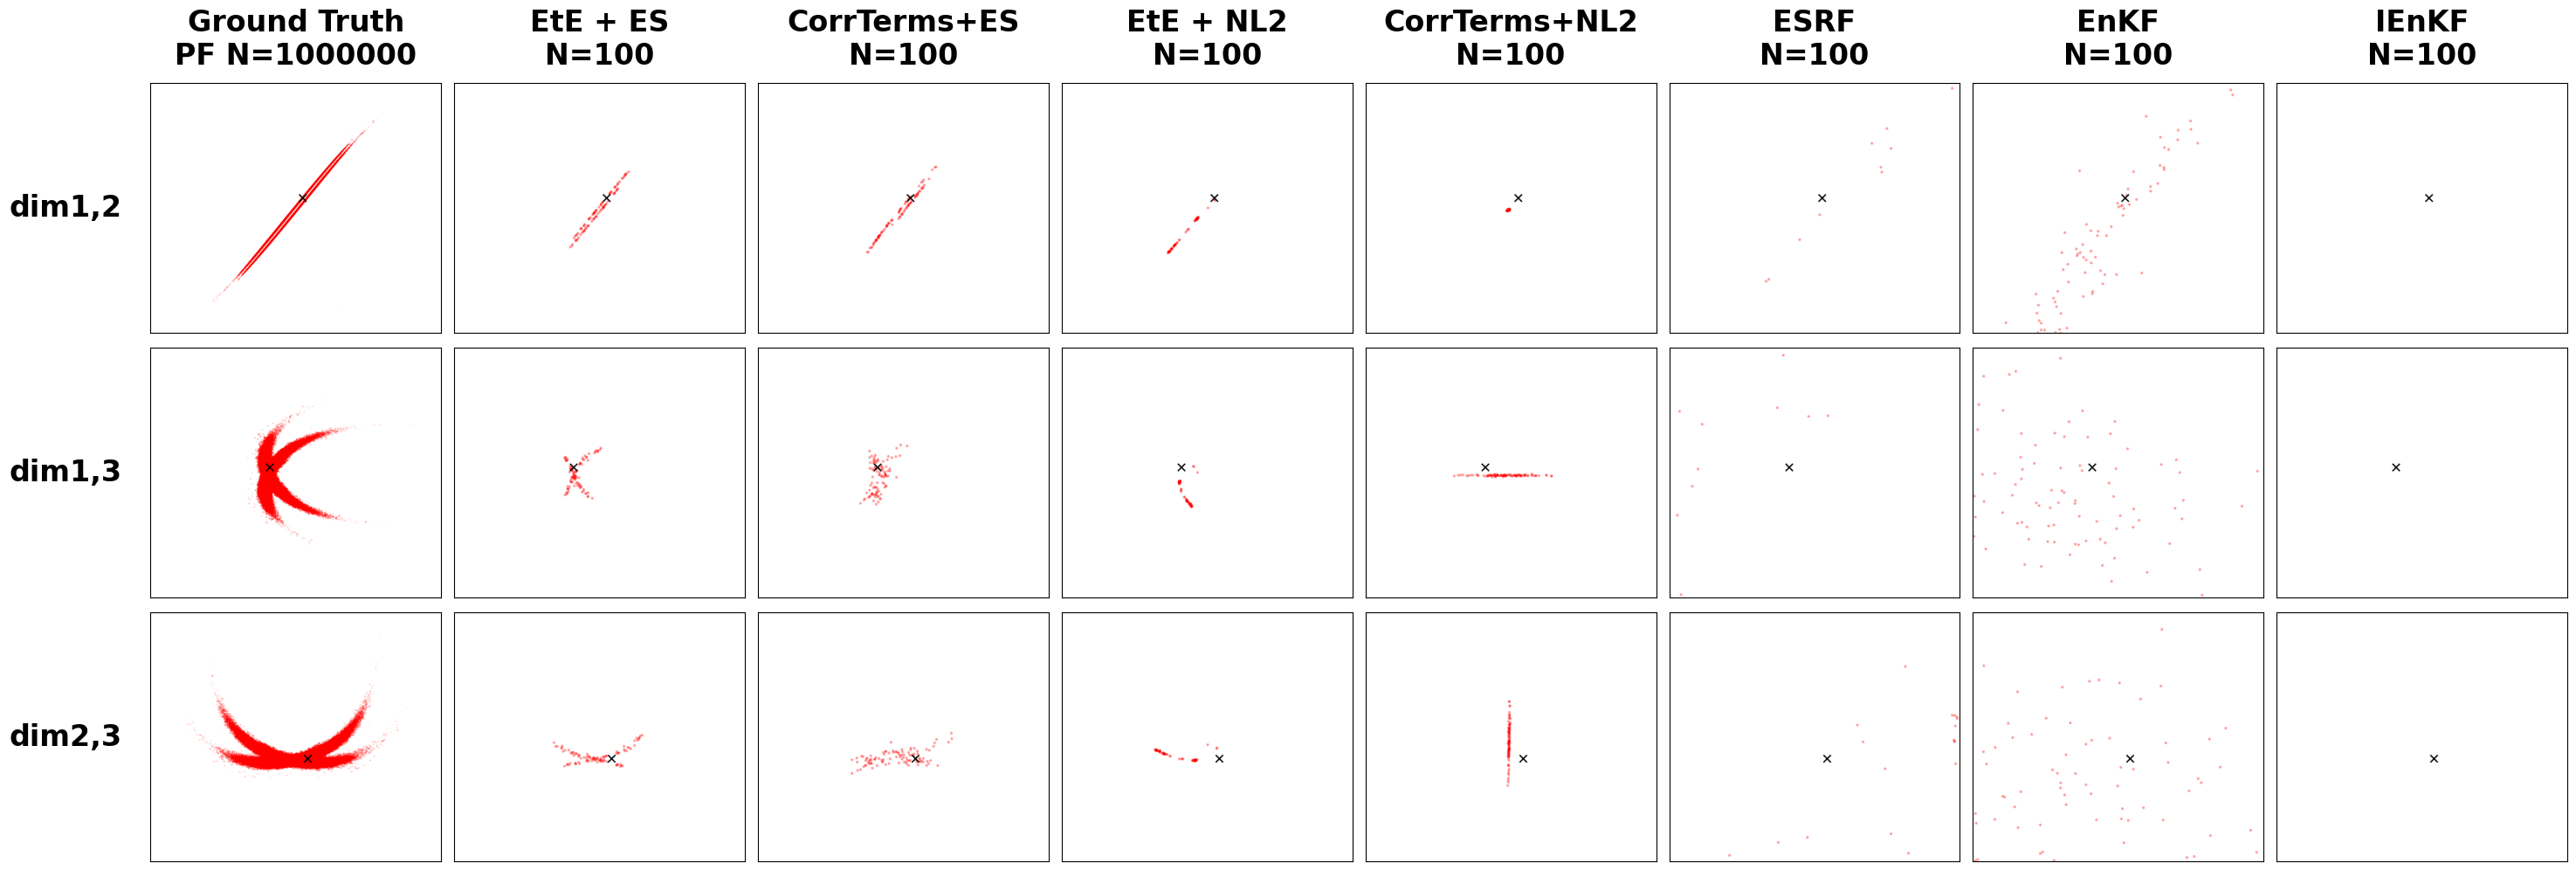

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step300_post_adaptive_transposed.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step300_post_adaptive_transposed.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step300_post_adaptive_transposed_legend.pdf
Saved 24 cropped high-resolution panel PDFs to: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step300_post_adaptive_transposed


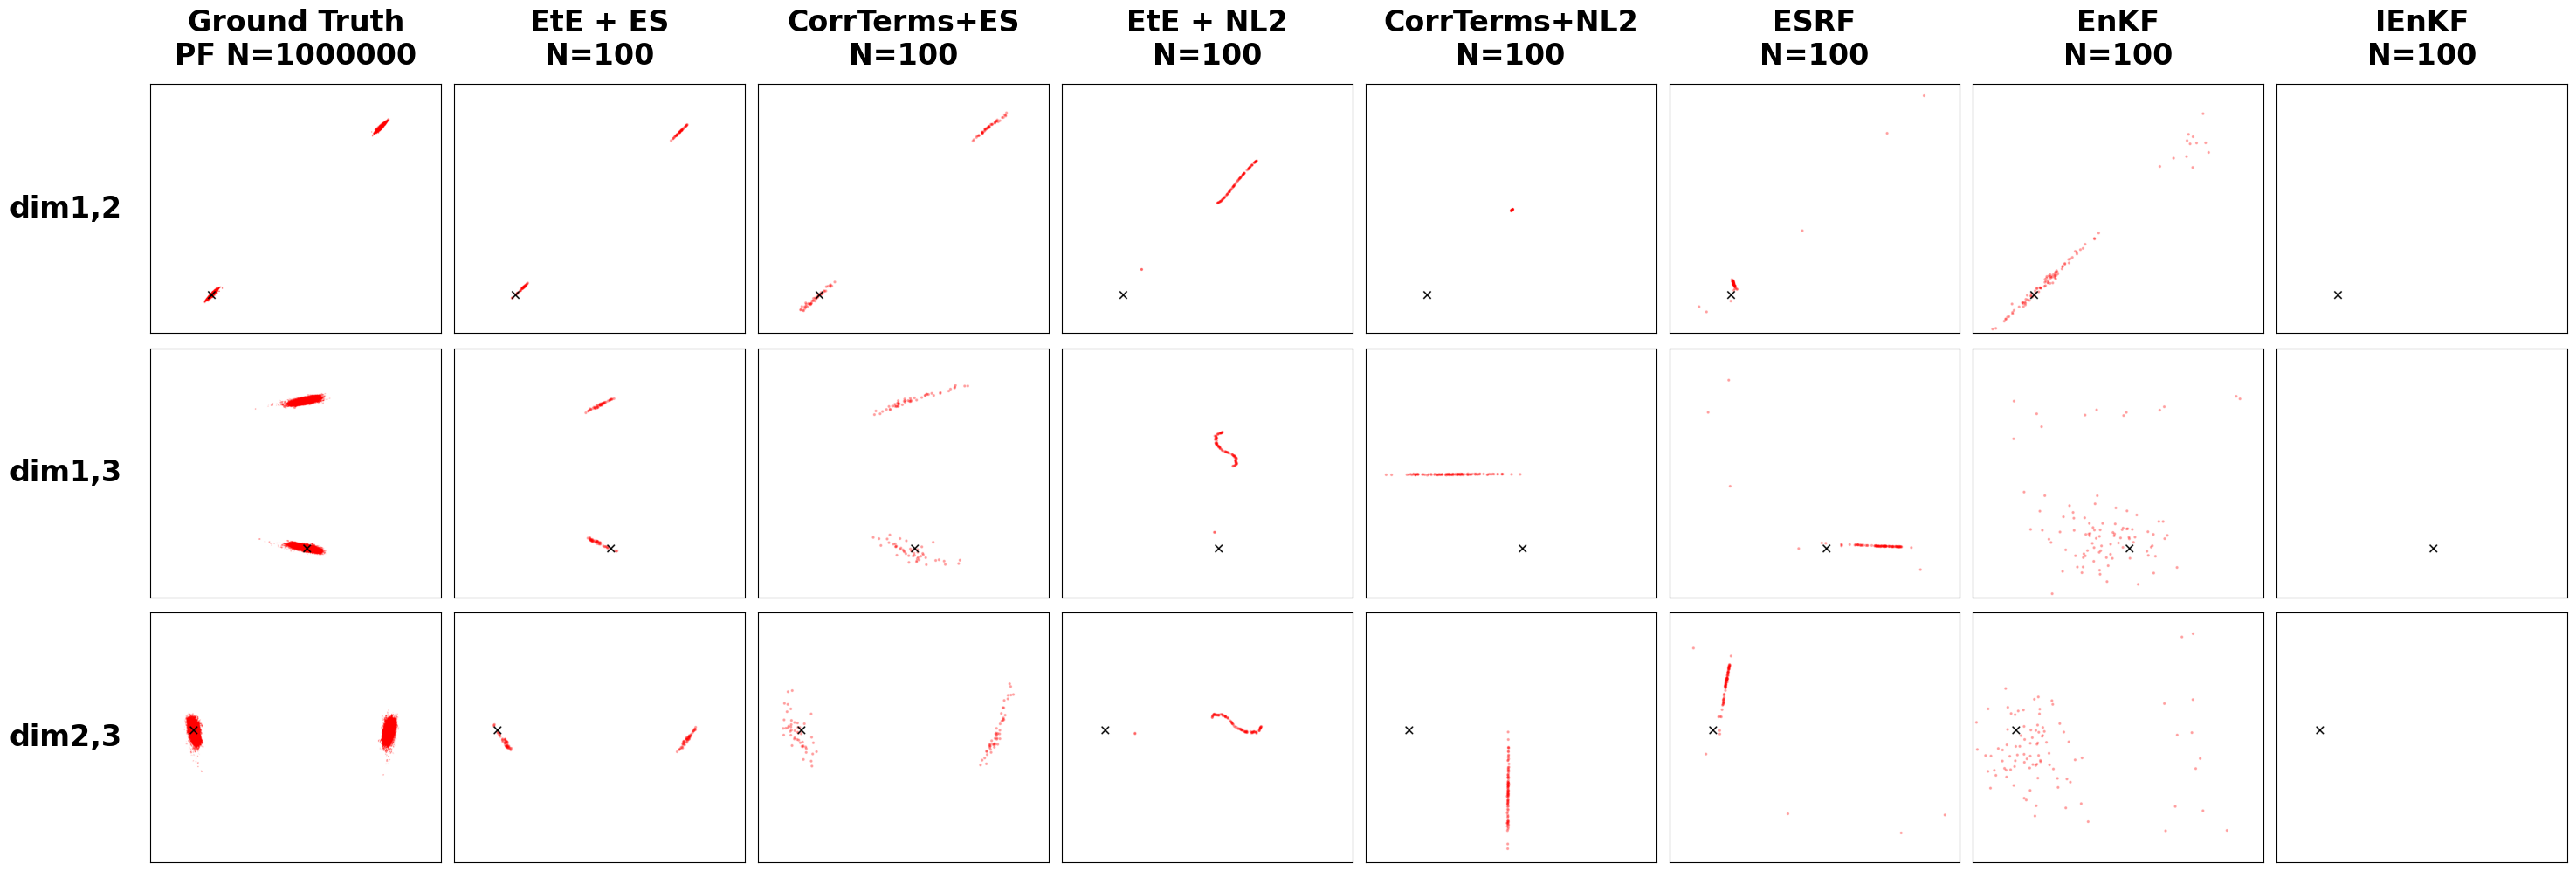

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step400_post_adaptive_transposed.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step400_post_adaptive_transposed.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step400_post_adaptive_transposed_legend.pdf
Saved 24 cropped high-resolution panel PDFs to: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step400_post_adaptive_transposed


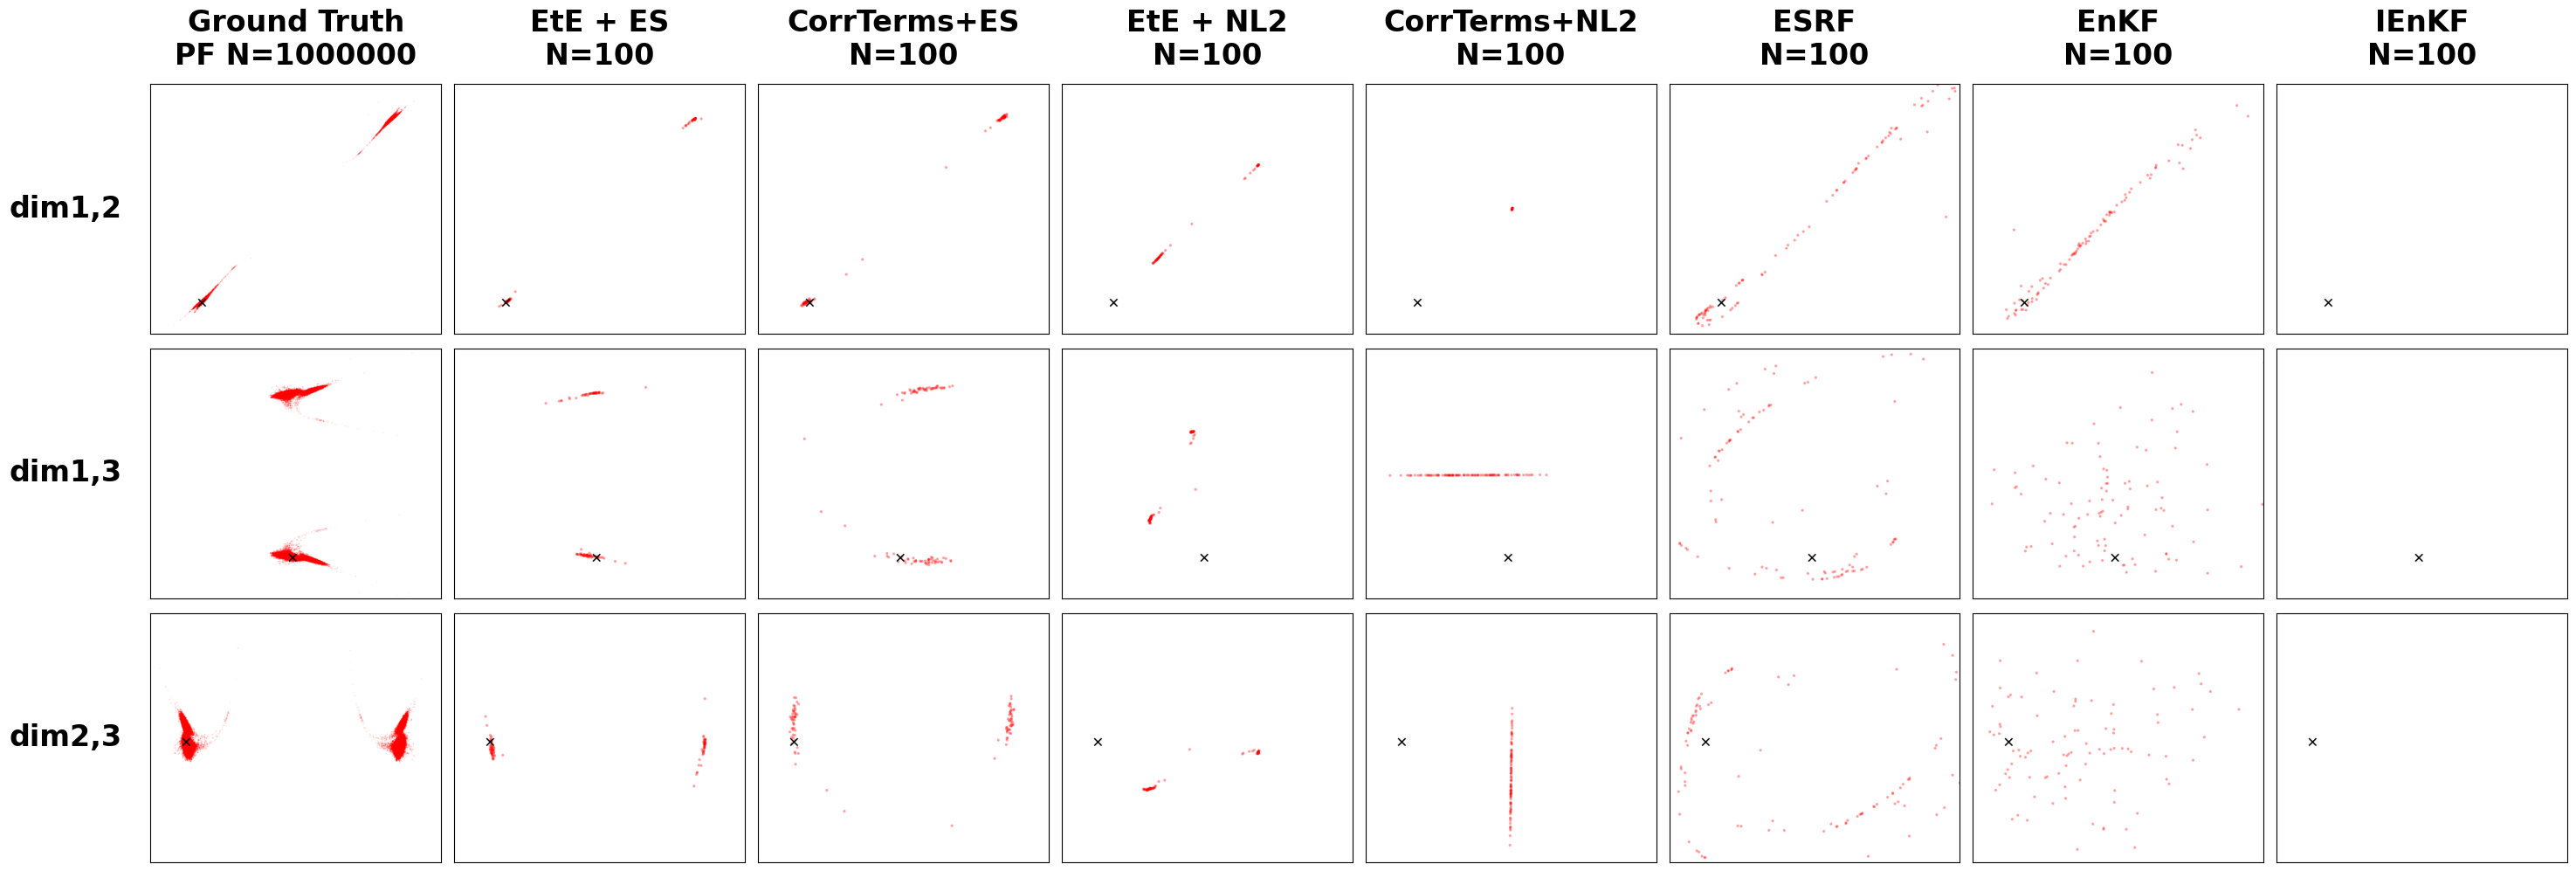

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step200_post_adaptive_transposed.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step200_post_adaptive_transposed.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step200_post_adaptive_transposed_legend.pdf
Saved 24 cropped high-resolution panel PDFs to: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step200_post_adaptive_transposed


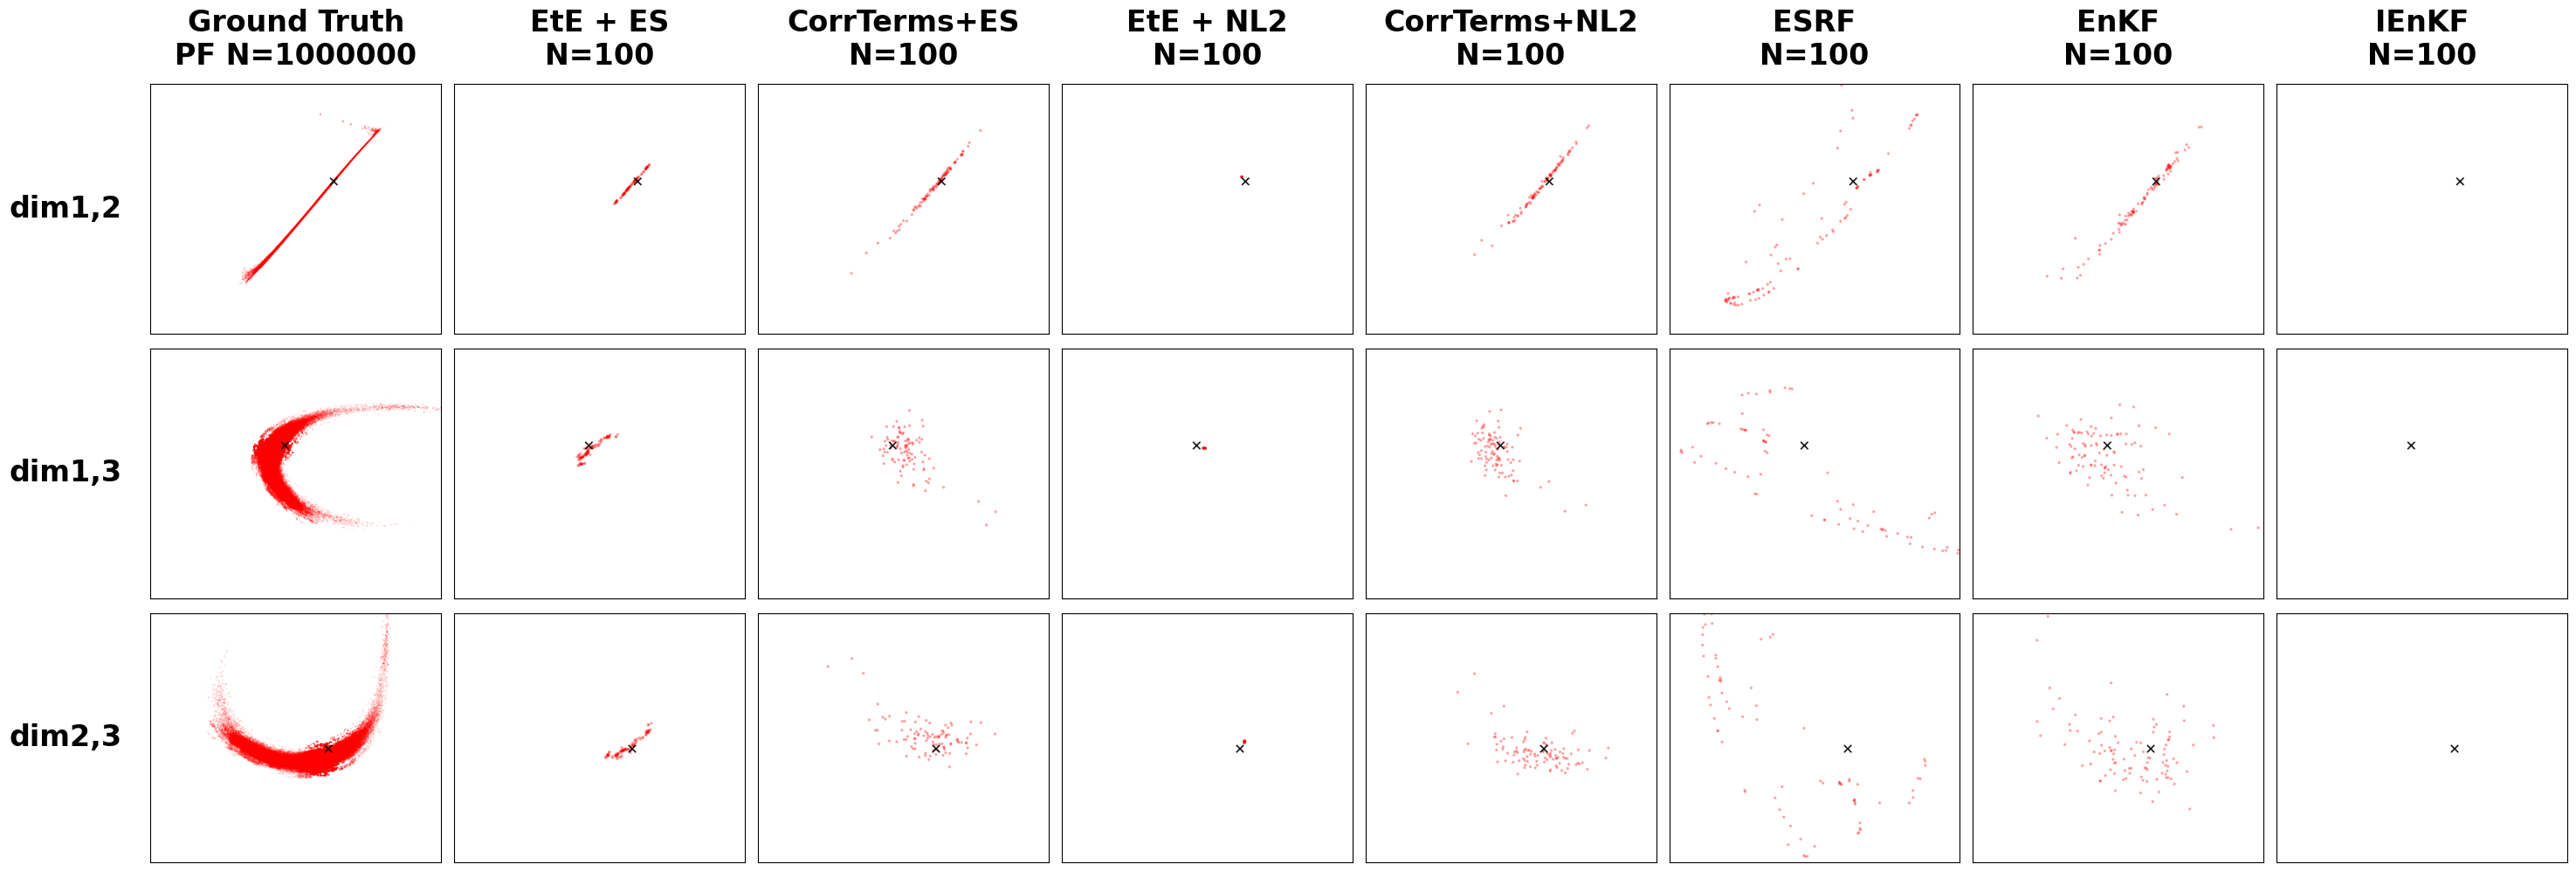

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step300_post_adaptive_transposed.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step300_post_adaptive_transposed.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step300_post_adaptive_transposed_legend.pdf
Saved 24 cropped high-resolution panel PDFs to: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step300_post_adaptive_transposed


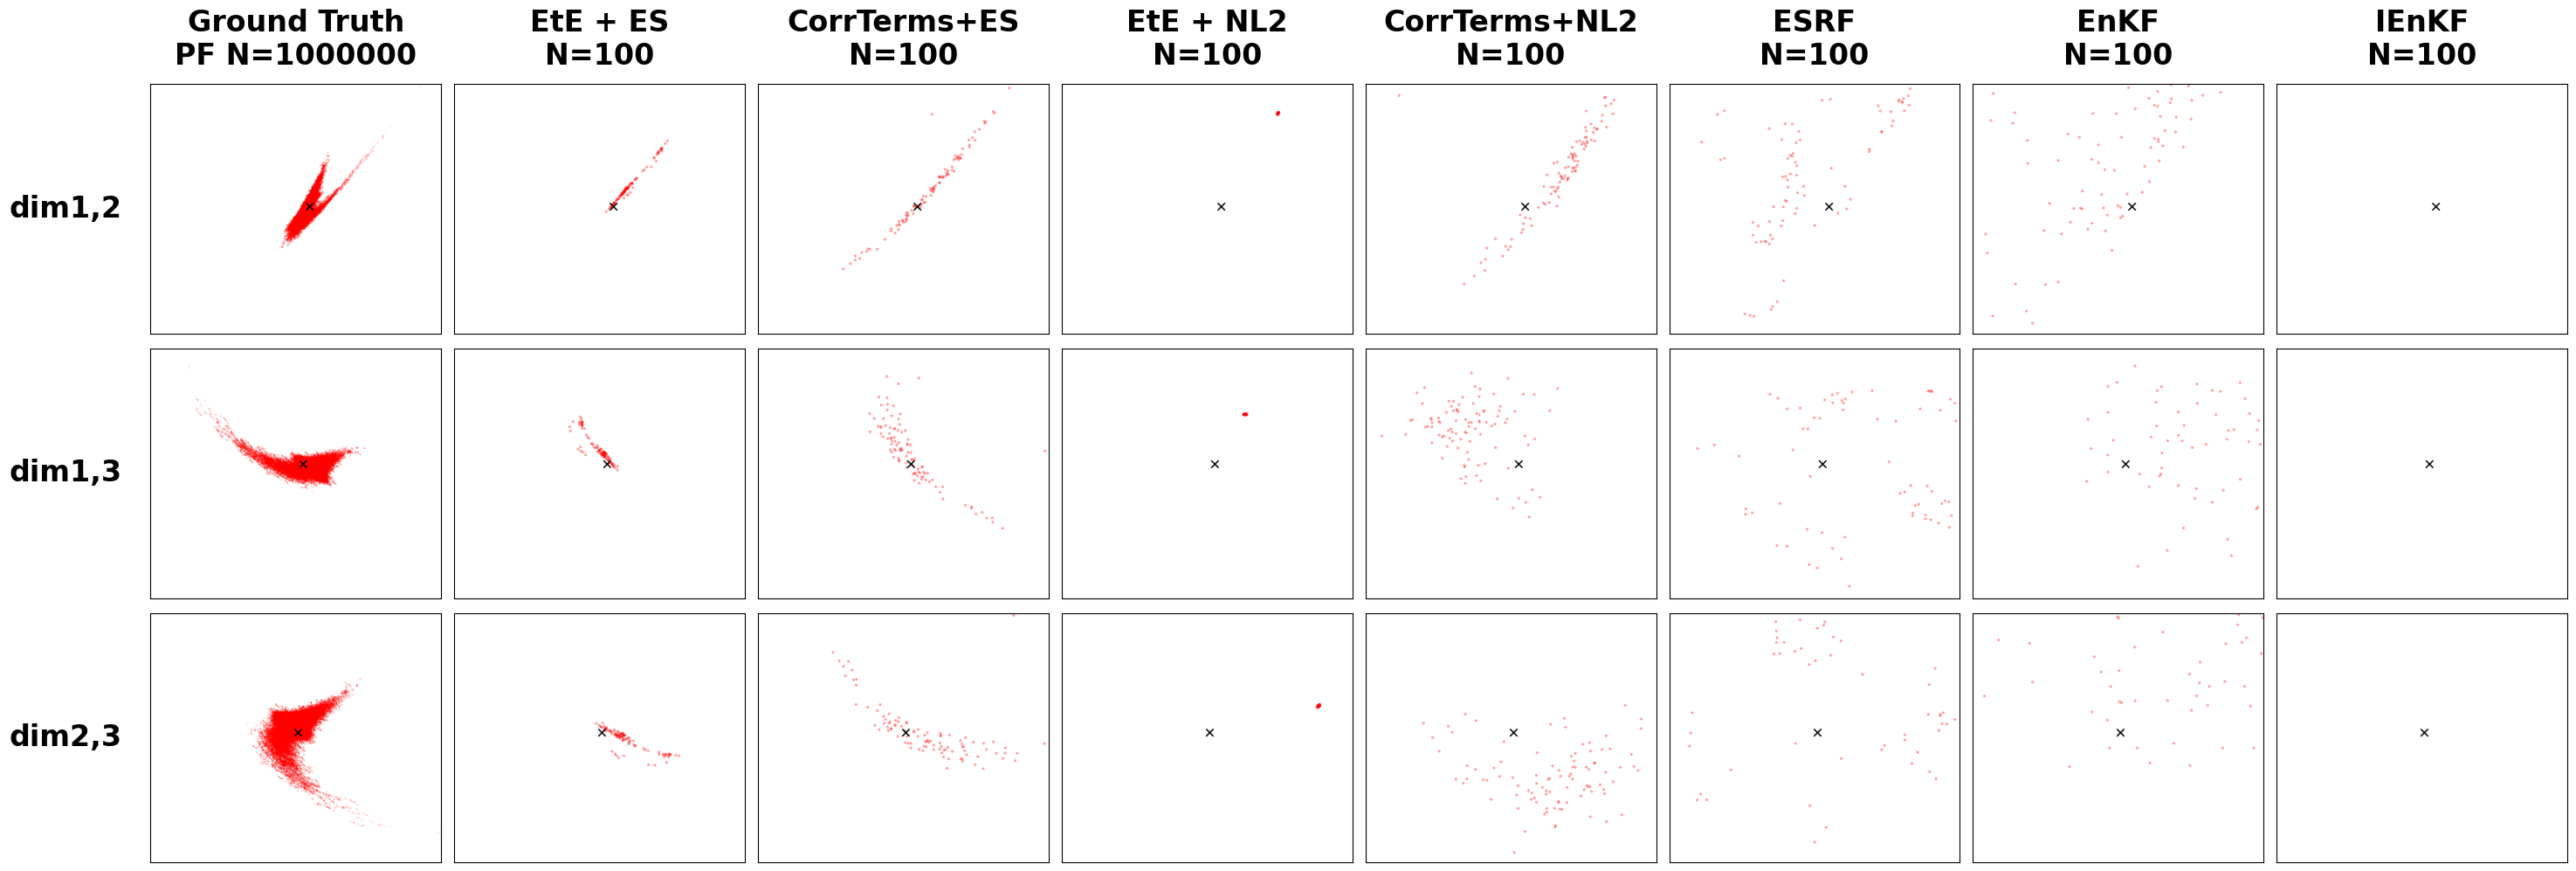

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step400_post_adaptive_transposed.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step400_post_adaptive_transposed.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step400_post_adaptive_transposed_legend.pdf
Saved 24 cropped high-resolution panel PDFs to: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step400_post_adaptive_transposed


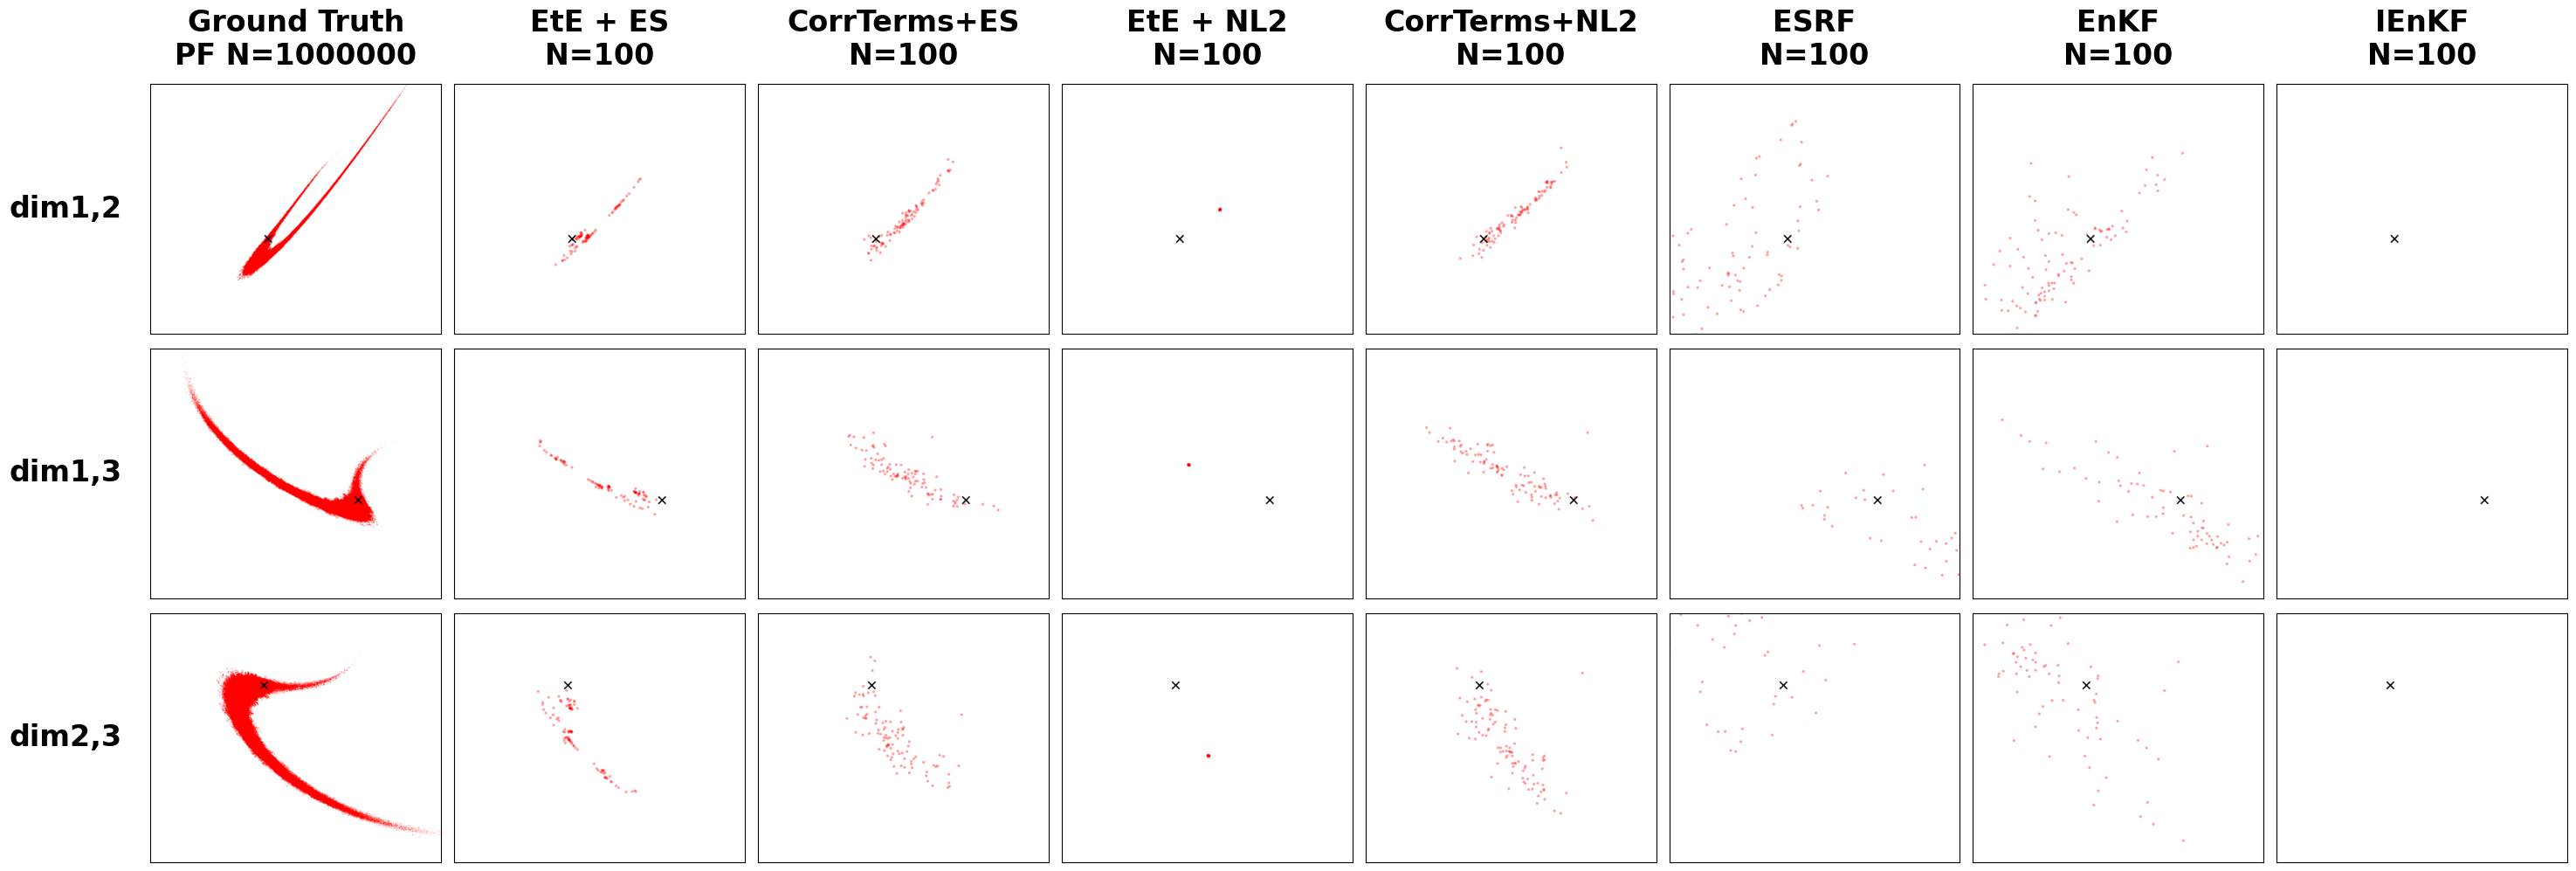

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step200_post_adaptive_transposed.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step200_post_adaptive_transposed.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step200_post_adaptive_transposed_legend.pdf
Saved 24 cropped high-resolution panel PDFs to: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step200_post_adaptive_transposed


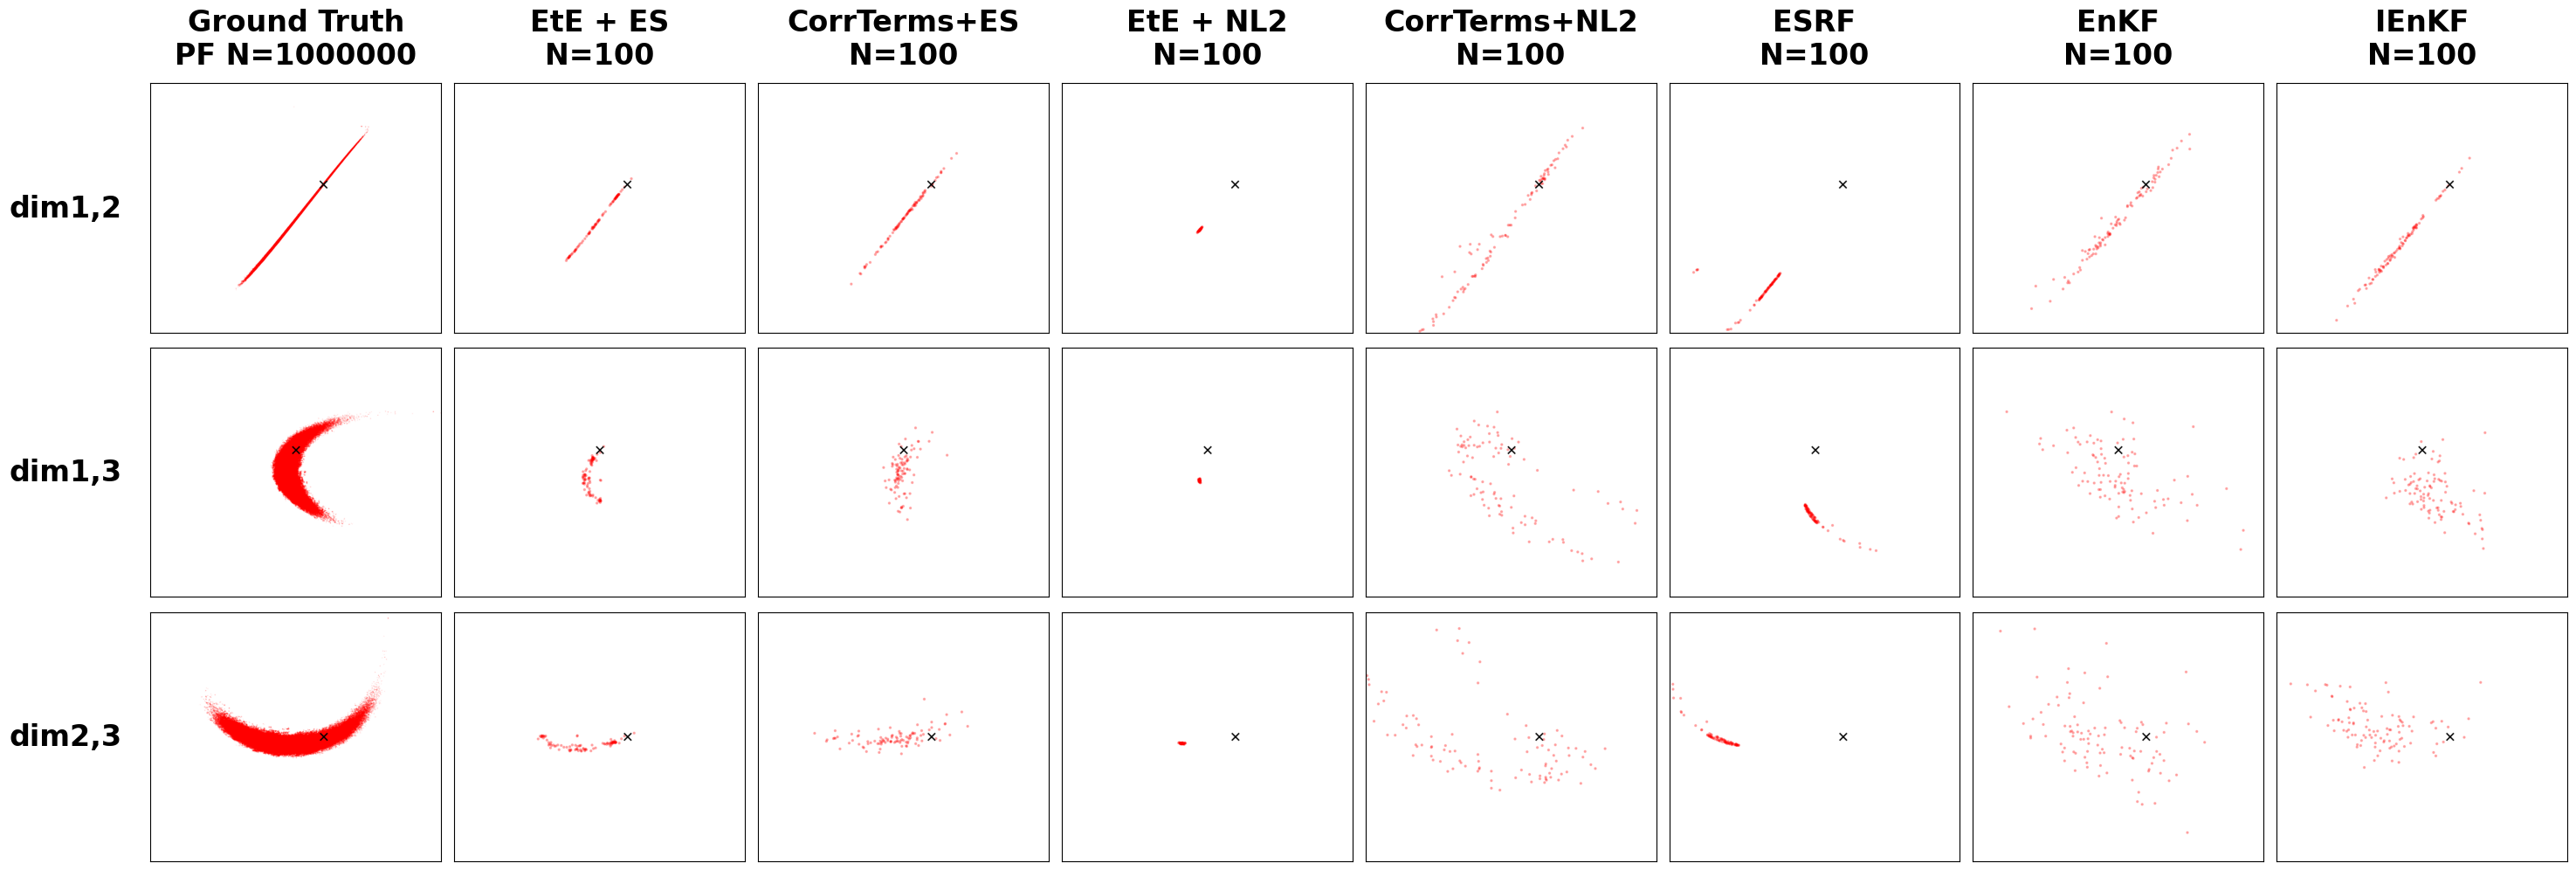

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step300_post_adaptive_transposed.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step300_post_adaptive_transposed.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step300_post_adaptive_transposed_legend.pdf
Saved 24 cropped high-resolution panel PDFs to: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step300_post_adaptive_transposed


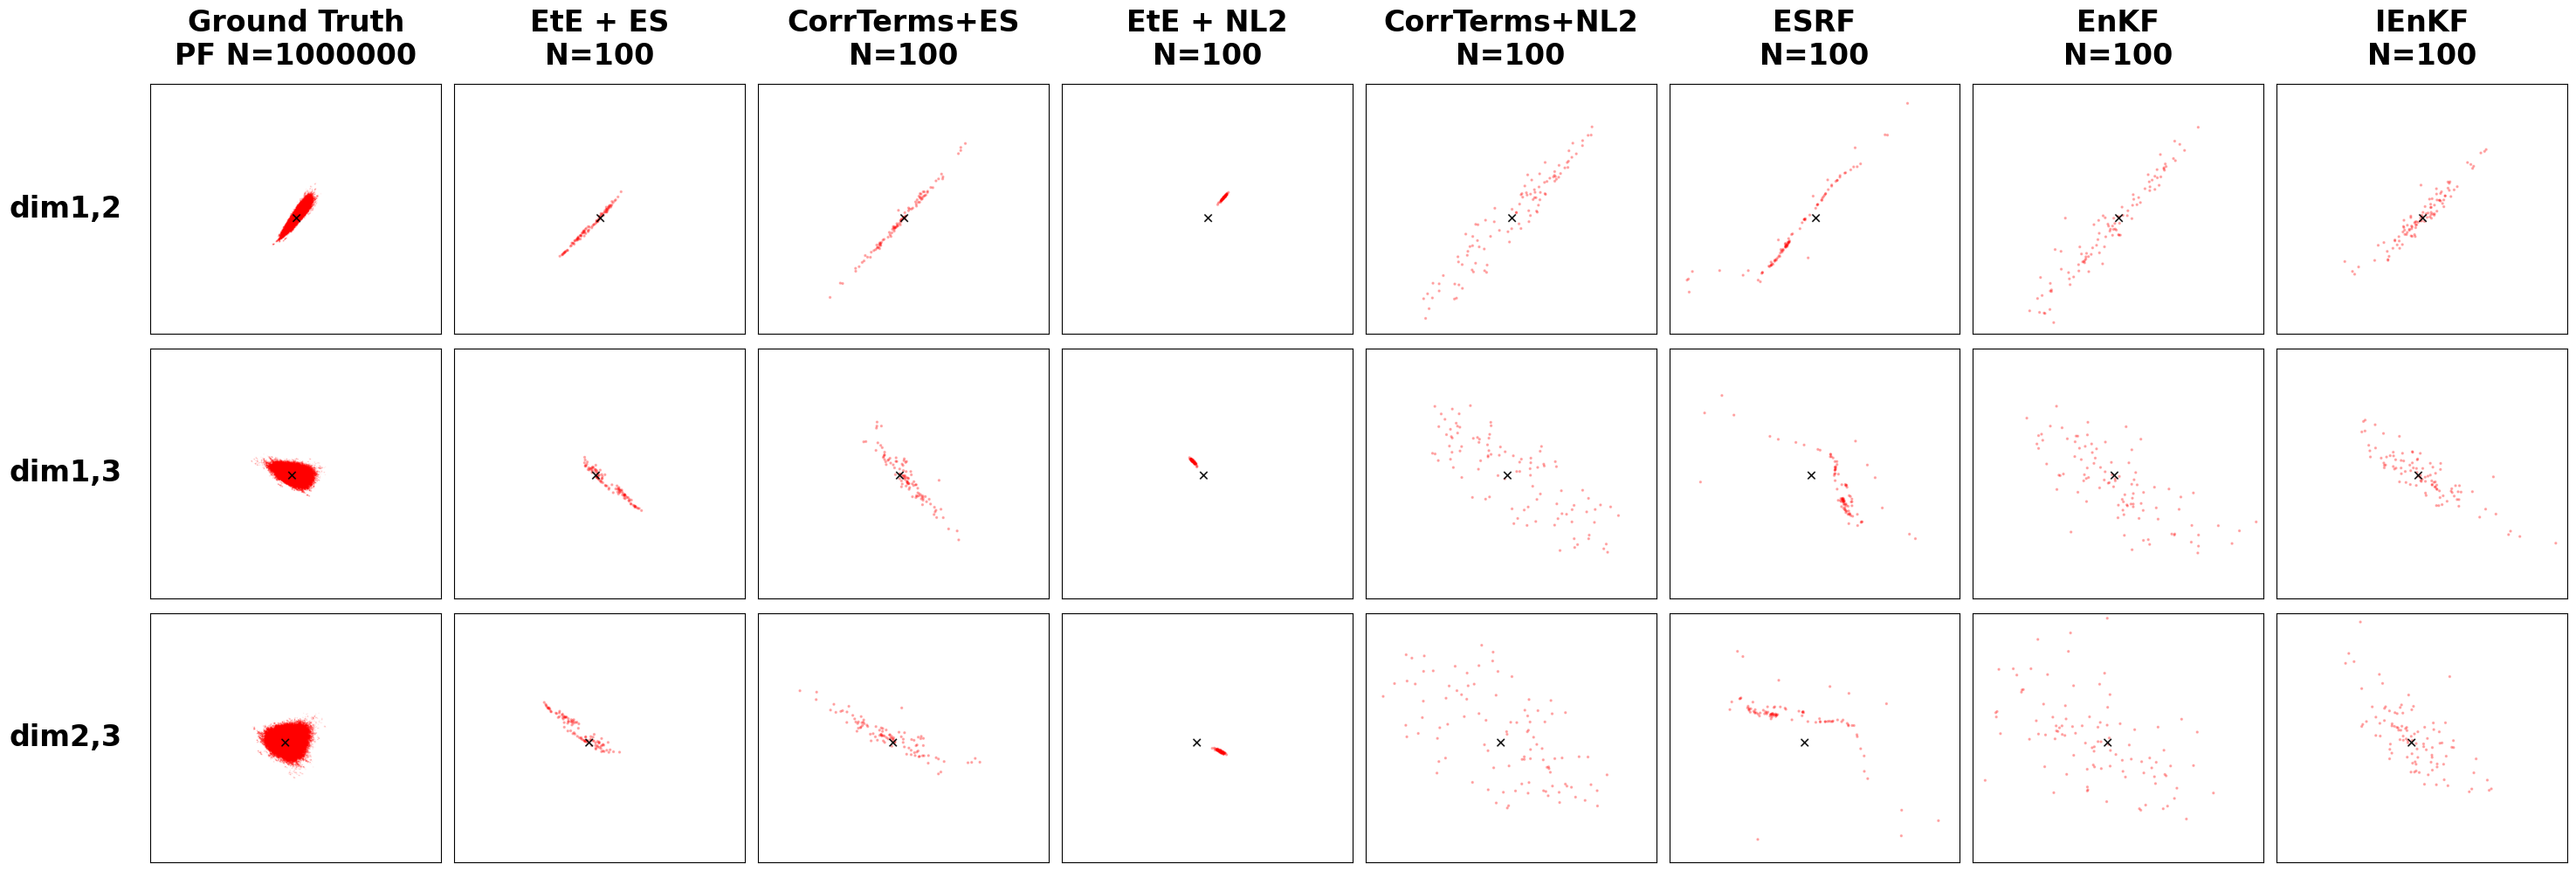

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step400_post_adaptive_transposed.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step400_post_adaptive_transposed.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step400_post_adaptive_transposed_legend.pdf
Saved 24 cropped high-resolution panel PDFs to: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step400_post_adaptive_transposed


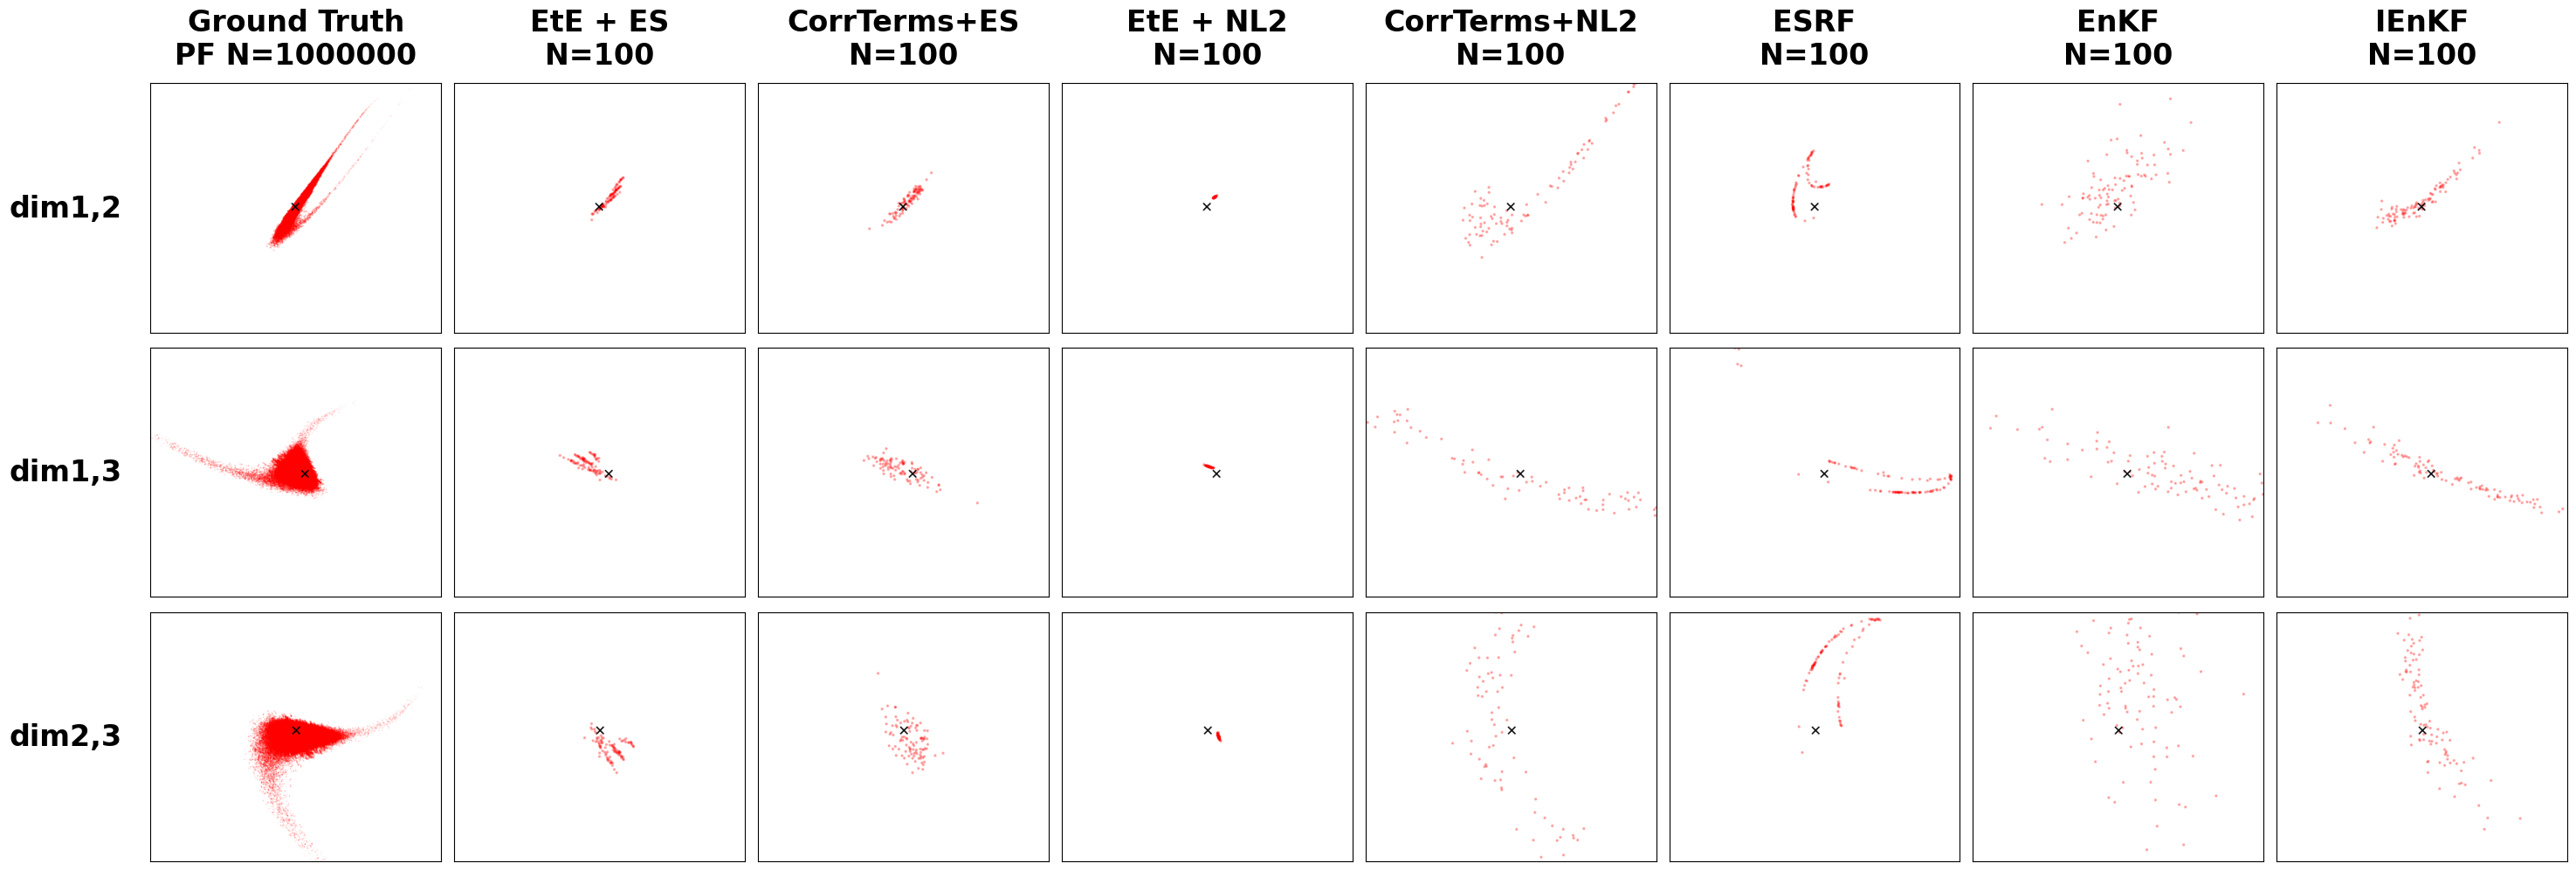

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step200_post_adaptive_pca_transposed.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step200_post_adaptive_pca_transposed.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step200_post_adaptive_pca_transposed_legend.pdf
Saved 8 cropped high-resolution panel PDFs to: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step200_post_adaptive_pca_transposed


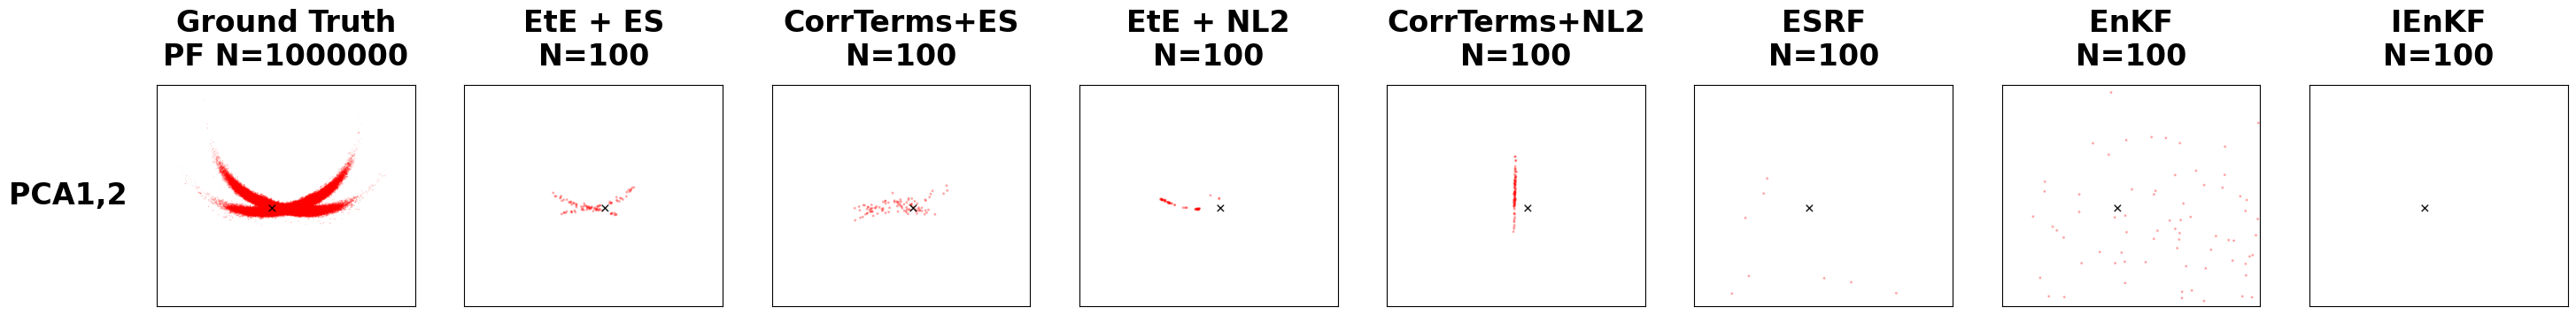

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step300_post_adaptive_pca_transposed.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step300_post_adaptive_pca_transposed.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step300_post_adaptive_pca_transposed_legend.pdf
Saved 8 cropped high-resolution panel PDFs to: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step300_post_adaptive_pca_transposed


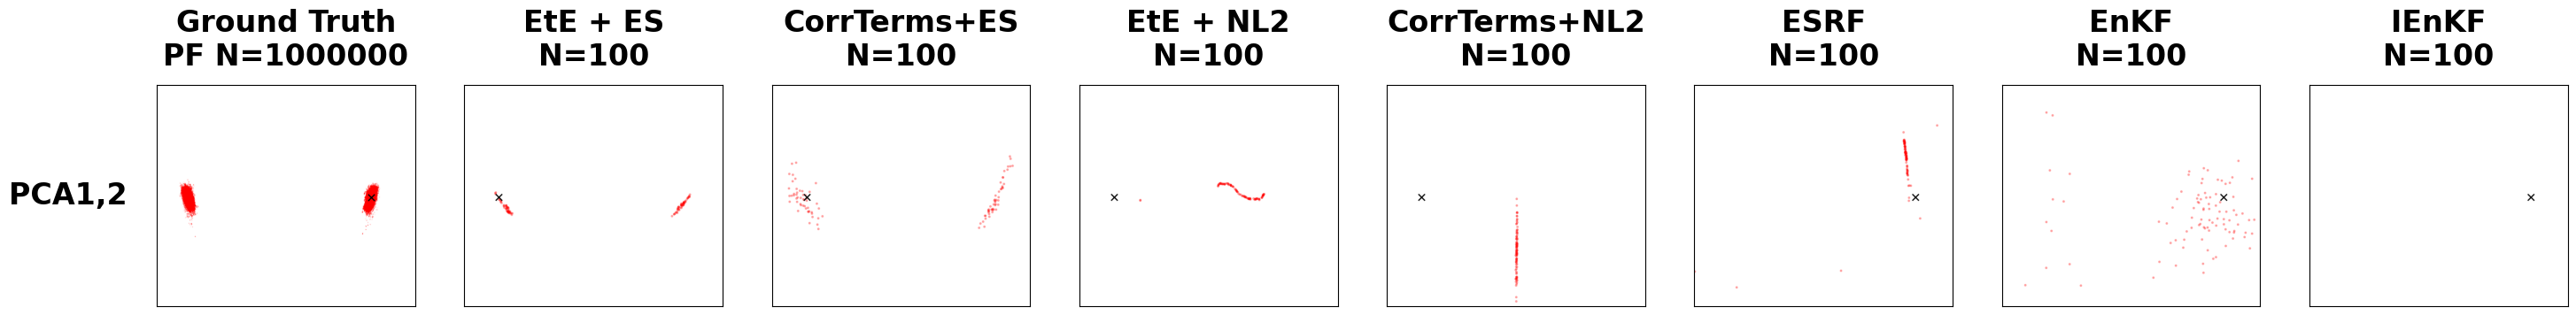

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step400_post_adaptive_pca_transposed.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step400_post_adaptive_pca_transposed.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step400_post_adaptive_pca_transposed_legend.pdf
Saved 8 cropped high-resolution panel PDFs to: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step400_post_adaptive_pca_transposed


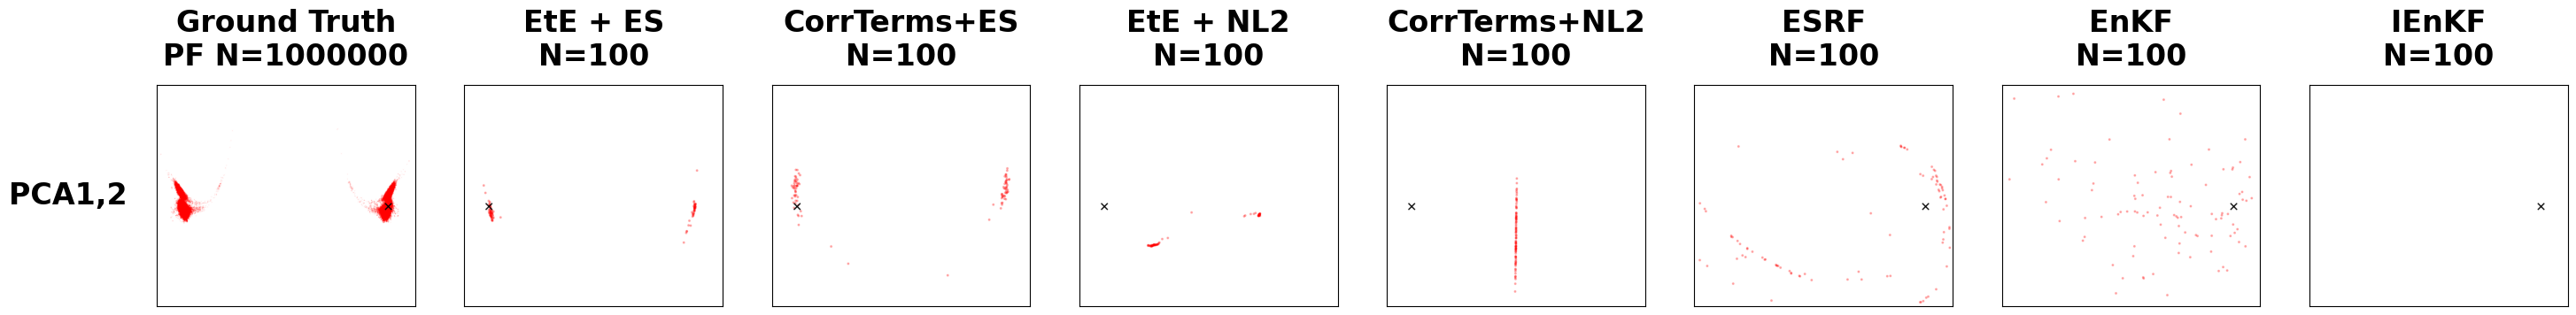

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step200_post_adaptive_pca_transposed.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step200_post_adaptive_pca_transposed.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step200_post_adaptive_pca_transposed_legend.pdf
Saved 8 cropped high-resolution panel PDFs to: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step200_post_adaptive_pca_transposed


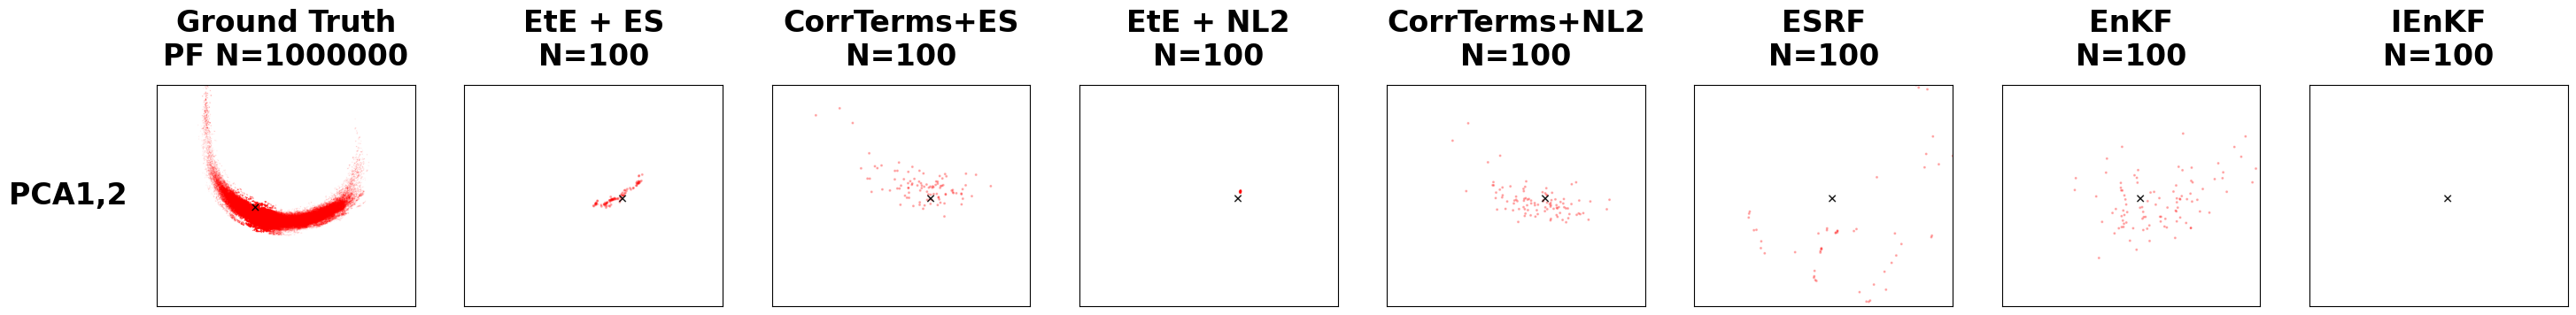

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step300_post_adaptive_pca_transposed.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step300_post_adaptive_pca_transposed.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step300_post_adaptive_pca_transposed_legend.pdf
Saved 8 cropped high-resolution panel PDFs to: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step300_post_adaptive_pca_transposed


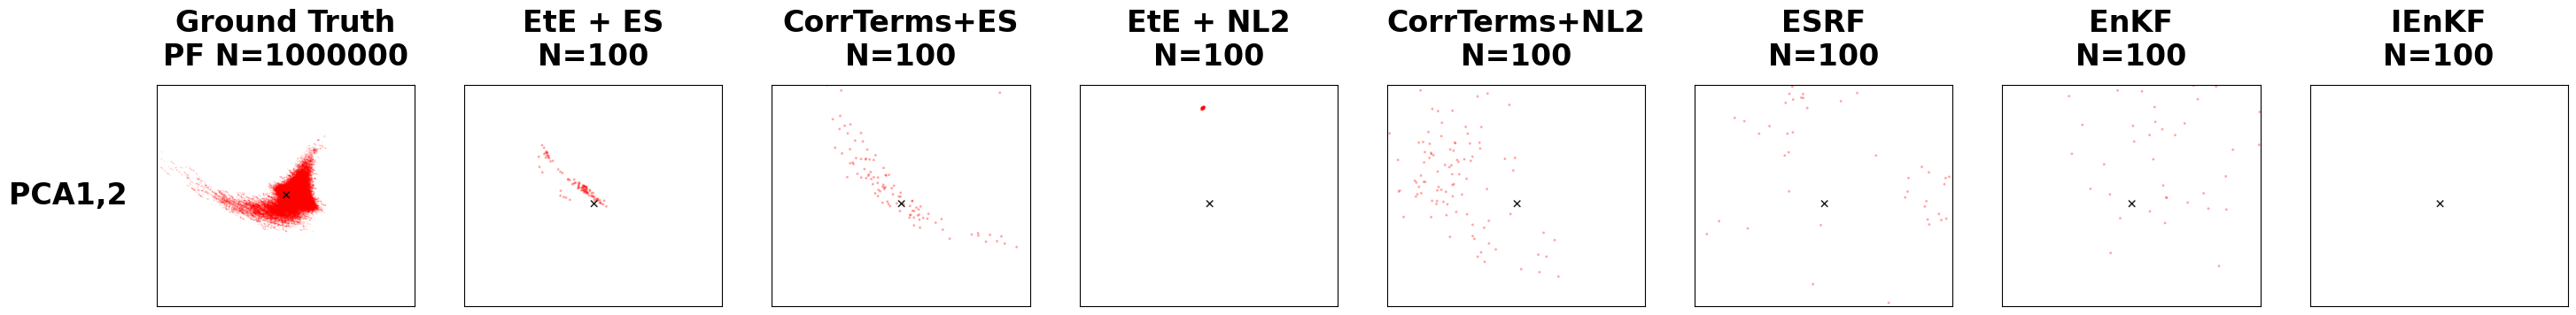

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step400_post_adaptive_pca_transposed.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step400_post_adaptive_pca_transposed.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step400_post_adaptive_pca_transposed_legend.pdf
Saved 8 cropped high-resolution panel PDFs to: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_arctan_step400_post_adaptive_pca_transposed


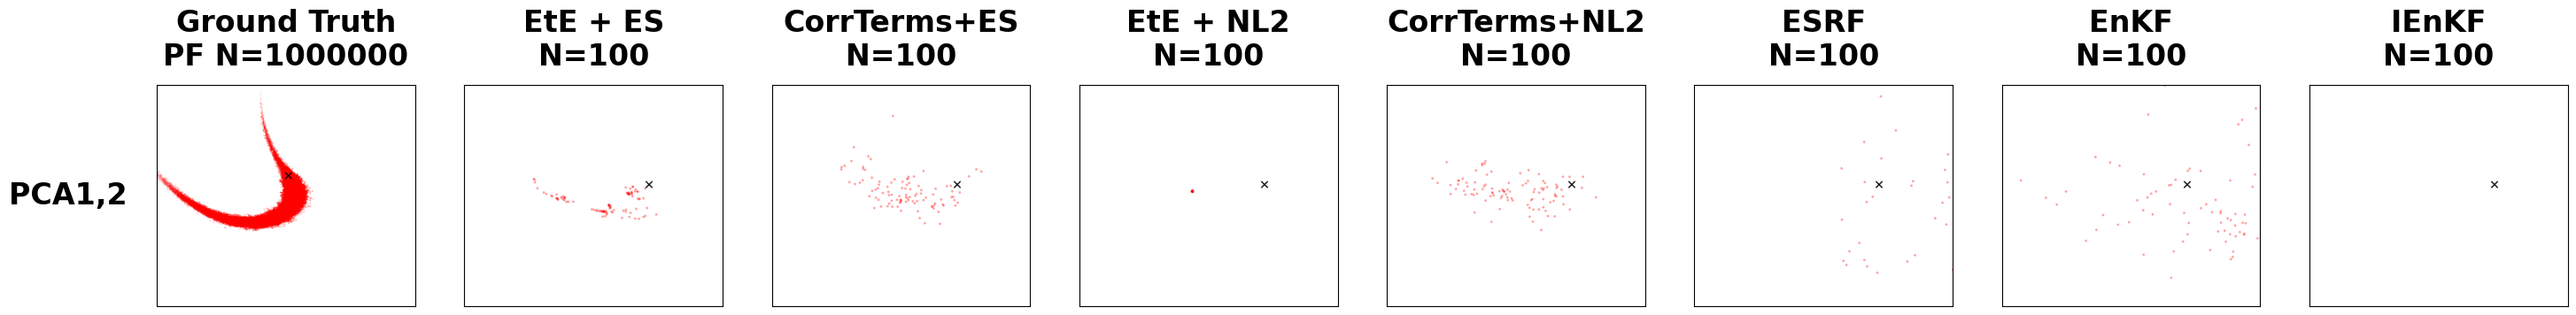

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step200_post_adaptive_pca_transposed.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step200_post_adaptive_pca_transposed.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step200_post_adaptive_pca_transposed_legend.pdf
Saved 8 cropped high-resolution panel PDFs to: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step200_post_adaptive_pca_transposed


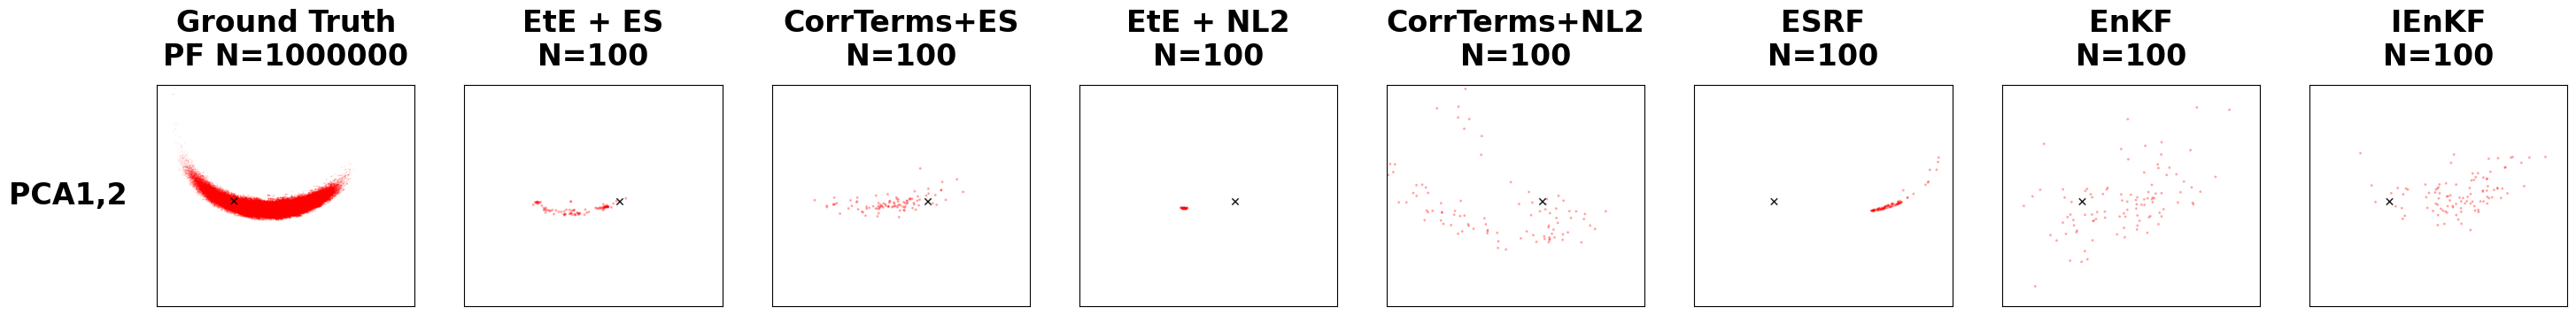

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step300_post_adaptive_pca_transposed.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step300_post_adaptive_pca_transposed.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step300_post_adaptive_pca_transposed_legend.pdf
Saved 8 cropped high-resolution panel PDFs to: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step300_post_adaptive_pca_transposed


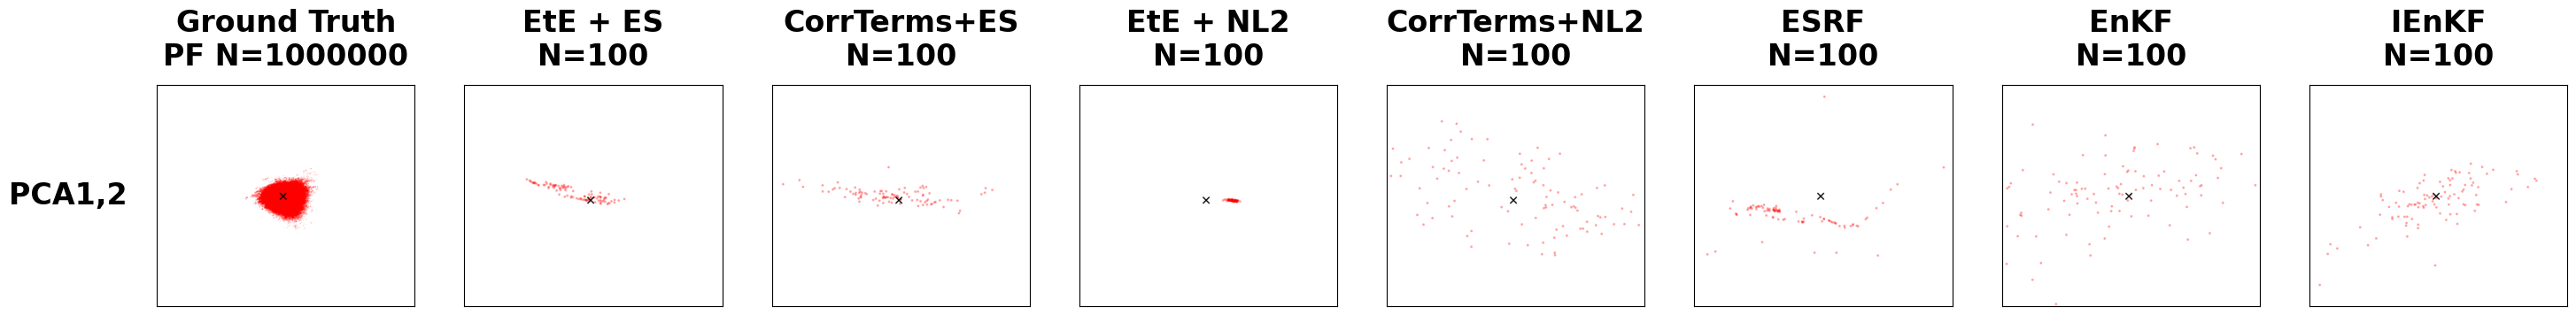

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step400_post_adaptive_pca_transposed.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step400_post_adaptive_pca_transposed.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step400_post_adaptive_pca_transposed_legend.pdf
Saved 8 cropped high-resolution panel PDFs to: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_identity_step400_post_adaptive_pca_transposed


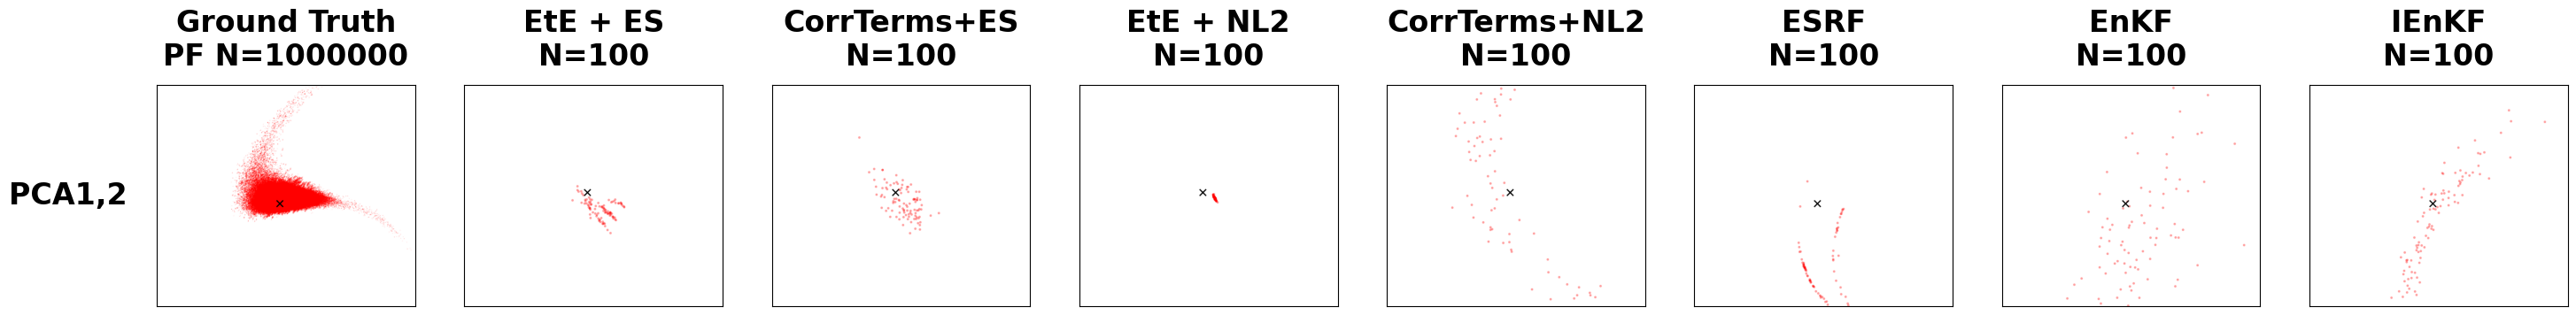

In [8]:
def build_columns_for_grid(obs_bundle):
    cols = [{'type': 'pf', 'method_label': 'Ground Truth', 'dir': obs_bundle['pf_dir'], 'N': None, 'obs_fn': obs_bundle['obs_fn']}]

    for spec in obs_bundle['training_specs']:
        for N in N_LIST:
            cols.append({
                'type': 'method',
                'method_label': spec['label'],
                'dir': spec['dir'],
                'N': N,
                'group': 'train',
                'obs_fn': obs_bundle['obs_fn'],
            })

    for spec in obs_bundle['benchmark_specs']:
        for N in N_LIST:
            cols.append({
                'type': 'method',
                'method_label': spec['label'],
                'dir': spec['dir'],
                'N': N,
                'group': 'classic',
                'obs_fn': obs_bundle['obs_fn'],
            })

    return cols


def view_to_dim_label(view: str) -> str:
    mapping = {
        '12': 'dim1,2',
        '13': 'dim1,3',
        '23': 'dim2,3',
        'PCA12': 'PCA1,2',
        'xy': 'dim1,2',
        'xz': 'dim1,3',
        'yz': 'dim2,3',
    }
    return mapping.get(view, str(view))


def format_method_header(col):
    from textwrap import fill

    method_line = fill(str(col.get('method_label', '')), width=int(GRID_COL_TITLE_WRAP))
    if col['type'] == 'pf':
        n_line = f'PF N={PF_N}'
    else:
        n_line = f"N={col['N']}"
    return f"{method_line}\n{n_line}"


def safe_grid_filename_part(value):
    value = re.sub(r'[^A-Za-z0-9._-]+', '_', str(value)).strip('_')
    return value or 'item'


def expected_grid_slots(n_rows, n_cols):
    return {(r, c) for r in range(n_rows) for c in range(n_cols)}


def validate_grid_panel_records(panel_records, expected_shape, expected_panel_count):
    expected_rows, expected_cols = expected_shape
    expected_slots = expected_grid_slots(expected_rows, expected_cols)
    actual_slots = {(rec['row'], rec['col']) for rec in panel_records}
    duplicate_slots = sorted(
        slot for slot in actual_slots
        if sum((rec['row'], rec['col']) == slot for rec in panel_records) > 1
    )
    missing_slots = sorted(expected_slots - actual_slots)
    extra_slots = sorted(actual_slots - expected_slots)

    errors = []
    if len(panel_records) != expected_panel_count:
        errors.append(f'expected {expected_panel_count} panels, found {len(panel_records)}')
    if duplicate_slots:
        errors.append(f'duplicate panel slots: {duplicate_slots}')
    if missing_slots:
        errors.append(f'missing panel slots: {missing_slots}')
    if extra_slots:
        errors.append(f'extra panel slots: {extra_slots}')

    missing_sources = [str(rec.get('path')) for rec in panel_records if not Path(rec.get('path', '')).exists()]
    if missing_sources:
        errors.append('missing source images: ' + ', '.join(missing_sources[:5]))

    if errors:
        raise RuntimeError('Cannot export cropped panel PDFs for this grid: ' + '; '.join(errors))


def save_cropped_grid_panel_images(
    grid_png_path,
    panel_records,
    step,
    obs_fn,
    expected_shape,
    expected_panel_count=EXPECTED_GRID_PANEL_COUNT,
    panel_dpi=PANEL_PDF_DPI,
):
    panel_dir = Path(grid_png_path).with_suffix('')
    validate_grid_panel_records(panel_records, expected_shape, expected_panel_count)
    panel_dir.mkdir(parents=True, exist_ok=True)

    for stale_file in list(panel_dir.glob('*.pdf')) + list(panel_dir.glob('*.png')):
        stale_file.unlink()

    saved_paths = []
    for rec in sorted(panel_records, key=lambda item: (item['row'], item['col'])):
        src = Path(rec['path'])
        img = plt.imread(str(src))
        img = crop_image(
            img,
            left_pct=CROP_LEFT_PCT,
            right_pct=CROP_RIGHT_PCT,
            top_pct=CROP_TOP_PCT,
            bottom_pct=CROP_BOTTOM_PCT,
        )
        method = safe_grid_filename_part(rec.get('method_label', 'method'))
        view = safe_grid_filename_part(rec.get('view', 'view'))
        obs_name = safe_grid_filename_part(obs_fn)
        n_value = rec.get('N')
        n_part = f'N{n_value}' if n_value is not None else f'PFN{PF_N}'
        filename = f"timestep{step}_{obs_name}_{method}_{n_part}_{view}_r{rec['row']:02d}_c{rec['col']:02d}.pdf"
        out_path = panel_dir / filename

        h, w = img.shape[:2]
        panel_fig = plt.figure(figsize=(w / panel_dpi, h / panel_dpi), dpi=panel_dpi, frameon=False)
        panel_ax = panel_fig.add_axes([0, 0, 1, 1])
        panel_ax.imshow(img, interpolation='none')
        panel_ax.set_axis_off()
        panel_fig.savefig(out_path, format='pdf', dpi=panel_dpi, bbox_inches=None, pad_inches=0)
        plt.close(panel_fig)
        saved_paths.append(out_path)

    if len(saved_paths) != expected_panel_count:
        raise RuntimeError(f'Saved {len(saved_paths)} panel PDFs, expected {expected_panel_count}: {panel_dir}')

    print(f'Saved {len(saved_paths)} cropped high-resolution panel PDFs to:', panel_dir)
    return panel_dir


def save_grid_state_ensemble_legend(grid_png_path):
    from matplotlib.lines import Line2D

    out = Path(grid_png_path).with_name(f'{Path(grid_png_path).stem}_legend.pdf')
    handles = [
        Line2D(
            [0],
            [0],
            marker='x',
            linestyle='None',
            color='black',
            markeredgewidth=1.8,
            markersize=8,
            label='True state',
        ),
        Line2D(
            [0],
            [0],
            marker='o',
            linestyle='None',
            color='red',
            markerfacecolor='red',
            markeredgecolor='red',
            markersize=6,
            label='Ensemble',
        ),
    ]
    legend_fig = plt.figure(figsize=(3.1, 0.38))
    legend_fig.legend(
        handles=handles,
        labels=[h.get_label() for h in handles],
        loc='center',
        ncol=2,
        frameon=False,
        handletextpad=0.45,
        columnspacing=1.4,
        borderaxespad=0,
        fontsize=TICK_FONTSIZE,
    )
    legend_fig.savefig(out, format='pdf', bbox_inches='tight', pad_inches=0.01)
    plt.close(legend_fig)
    print('Saved:', out)
    return out


def expected_panel_count_for_grid(grid_views, n_cols):
    if list(grid_views) == BASE_VIEWS:
        expected = len(BASE_VIEWS) * n_cols
        if expected != EXPECTED_GRID_PANEL_COUNT:
            raise RuntimeError(f'Main grid should have {EXPECTED_GRID_PANEL_COUNT} panels, got {expected} ({len(BASE_VIEWS)} views x {n_cols} columns).')
        return EXPECTED_GRID_PANEL_COUNT
    return len(grid_views) * n_cols


def plot_grid_for_step(step: int, obs_fn=None, save=True, fig_save_dir=None, views=None, filename_tag=None, export_panel_pdfs=True):
    obs_fn = obs_fn or OBS_FN
    obs_bundle = obs_fn_bundles[obs_fn]
    cols = build_columns_for_grid(obs_bundle)
    grid_views = list(views or VIEWS)
    filename_tag = filename_tag or 'transposed'
    n_rows = len(grid_views)
    n_cols = len(cols)
    expected_panel_count = expected_panel_count_for_grid(grid_views, n_cols)
    fig_save_dir = Path(fig_save_dir or GRID_FIG_SAVE_DIR)
    fig_save_dir.mkdir(parents=True, exist_ok=True)
    panel_records = []

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(GRID_COL_WIDTH * n_cols, GRID_ROW_HEIGHT * n_rows),
        squeeze=False,
    )

    for c, col in enumerate(cols):
        axes[0, c].set_title(
            format_method_header(col),
            fontsize=GRID_COL_TITLE_FONTSIZE,
            fontweight='bold',
            linespacing=1.2,
            pad=16,
        )

    for r, view in enumerate(grid_views):
        for c, col in enumerate(cols):
            ax = axes[r, c]
            if col['type'] == 'pf':
                img_path = find_pf_image(step=step, view=view, pf_vis_dir=col['dir'])
            else:
                img_path = find_method_image(method_dir=col['dir'], N=col['N'], step=step, view=view)

            if img_path is not None and Path(img_path).exists():
                try:
                    img = plt.imread(str(img_path))
                    img = crop_image(
                        img,
                        left_pct=CROP_LEFT_PCT,
                        right_pct=CROP_RIGHT_PCT,
                        top_pct=CROP_TOP_PCT,
                        bottom_pct=CROP_BOTTOM_PCT,
                    )
                    ax.imshow(img)
                    panel_records.append({
                        'path': img_path,
                        'row': r,
                        'col': c,
                        'view': view,
                        'method_label': col.get('method_label'),
                        'N': col.get('N'),
                    })
                except Exception:
                    ax.text(0.5, 0.5, 'Read error', ha='center', va='center', fontsize=TICK_FONTSIZE)
                    ax.set_facecolor('#eeeeee')
            else:
                ax.text(0.5, 0.5, 'Missing', ha='center', va='center', fontsize=TICK_FONTSIZE)
                ax.set_facecolor('#f7f7f7')

            ax.set_xticks([])
            ax.set_yticks([])

            if c == 0:
                ax.set_ylabel(
                    view_to_dim_label(view),
                    rotation=0,
                    ha='right',
                    va='center',
                    labelpad=24,
                    fontsize=GRID_ROW_LABEL_FONTSIZE,
                    fontweight='bold',
                )

    plt.tight_layout()

    if save:
        out = fig_save_dir / f'grid_{obs_fn}_step{step}_{KIND}_{RANGE_MODE}_{filename_tag}.png'
        save_figure_png_pdf(fig, out, dpi=180, bbox_inches='tight')
        save_grid_state_ensemble_legend(out)
        if export_panel_pdfs:
            save_cropped_grid_panel_images(
                out,
                panel_records,
                step=step,
                obs_fn=obs_fn,
                expected_shape=(n_rows, n_cols),
                expected_panel_count=expected_panel_count,
            )

    plt.show()


def plot_pca_grid_for_step(step: int, obs_fn=None, save=True, fig_save_dir=None):
    return plot_grid_for_step(
        step,
        obs_fn=obs_fn,
        save=save,
        fig_save_dir=fig_save_dir,
        views=PCA_GRID_VIEWS,
        filename_tag='pca_transposed',
    )


for obs_fn in GRID_OBS_FN_DISPLAY:
    for step in STEP_LIST:
        plot_grid_for_step(step, obs_fn=obs_fn)

if RENDER_PCA_GRIDS:
    for obs_fn in GRID_OBS_FN_DISPLAY:
        for step in STEP_LIST:
            plot_pca_grid_for_step(step, obs_fn=obs_fn)


## Focus grid

The cell below renders the focused square/step-200 grid from the original notebook.


Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step200_focus.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step200_focus.pdf
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step200_focus_legend.pdf
Saved 24 cropped high-resolution panel PDFs to: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_multi_obs_notebook/grid_square_step200_focus


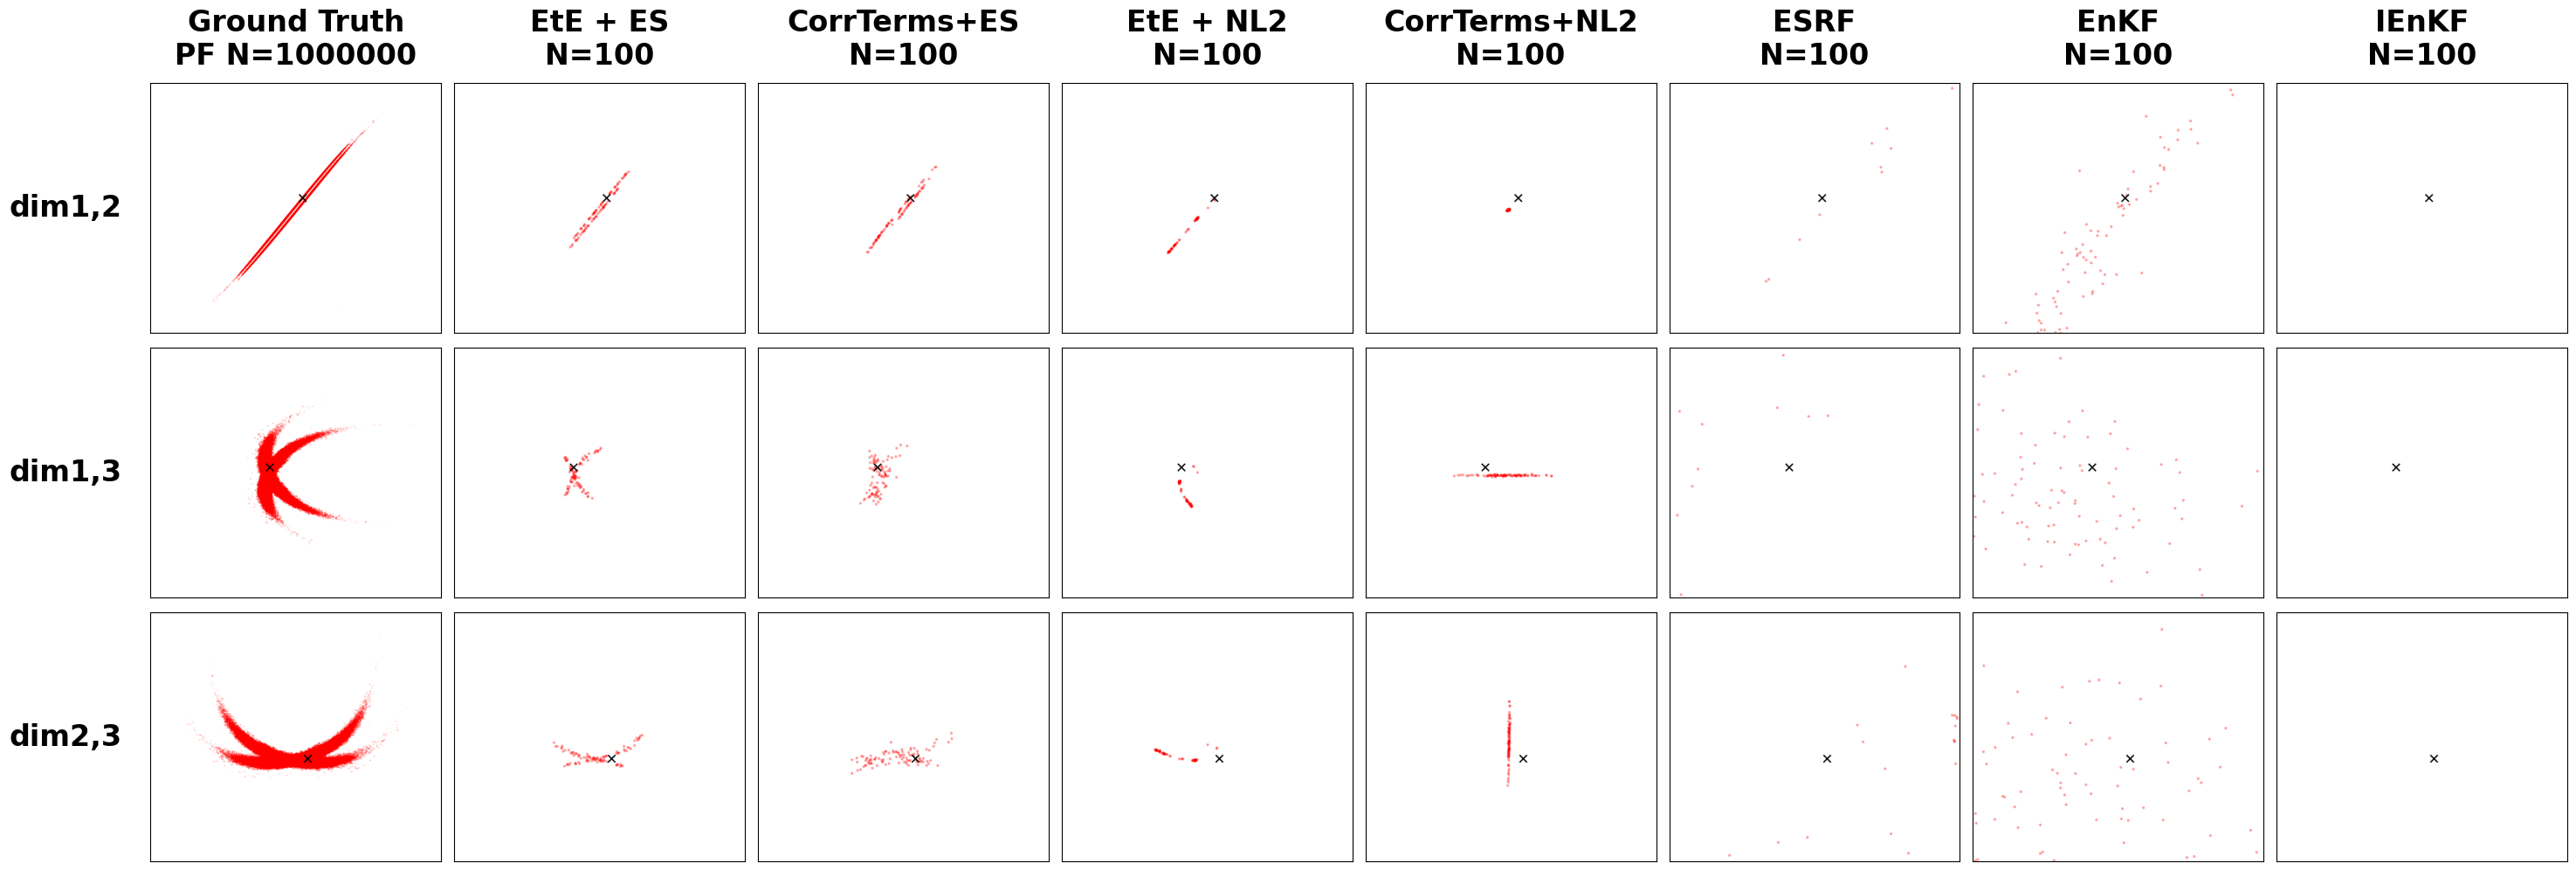

In [9]:
FOCUS_GRID_OBS_FN = 'square'
FOCUS_GRID_STEP = 200
FOCUS_GRID_VIEWS = ['12', '13', '23']
FOCUS_GRID_METHODS = [
    ('Ground Truth', None),
    ('EtE + ES', 'EtE + ES'),
    ('CorrTerms+ES', 'CorrTerms+ES'),
    ('EtE + NL2', 'EtE + NL2'),
    ('CorrTerms+NL2', 'CorrTerms+NL2'),
    ('ESRF', 'ESRF'),
    ('EnKF', 'EnKF'),
    ('IEnKF', 'IEnKF'),
]


def plot_focus_square_step200_grid(save=True, fig_save_dir=None):
    obs_bundle = obs_fn_bundles[FOCUS_GRID_OBS_FN]
    spec_lookup = {
        spec['label']: spec
        for spec in obs_bundle['training_specs'] + obs_bundle['benchmark_specs']
    }
    cols = [
        {'type': 'pf', 'method_label': 'Ground Truth', 'dir': obs_bundle['pf_dir'], 'N': None, 'obs_fn': FOCUS_GRID_OBS_FN}
    ]

    for display_label, source_label in FOCUS_GRID_METHODS[1:]:
        spec = spec_lookup.get(source_label)
        if spec is None:
            raise KeyError(f'Missing method for focus grid: {source_label}')
        cols.append({
            'type': 'method',
            'method_label': display_label,
            'dir': spec['dir'],
            'N': N_LIST[0],
            'group': spec['kind'],
            'obs_fn': FOCUS_GRID_OBS_FN,
        })

    n_rows = len(FOCUS_GRID_VIEWS)
    n_cols = len(cols)
    fig_save_dir = Path(fig_save_dir or GRID_FIG_SAVE_DIR)
    fig_save_dir.mkdir(parents=True, exist_ok=True)
    panel_records = []

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(GRID_COL_WIDTH * n_cols, GRID_ROW_HEIGHT * n_rows),
        squeeze=False,
    )

    for c, col in enumerate(cols):
        axes[0, c].set_title(
            format_method_header(col),
            fontsize=GRID_COL_TITLE_FONTSIZE,
            fontweight='bold',
            linespacing=1.2,
            pad=16,
        )

    for r, view in enumerate(FOCUS_GRID_VIEWS):
        for c, col in enumerate(cols):
            ax = axes[r, c]
            if col['type'] == 'pf':
                img_path = find_pf_image(step=FOCUS_GRID_STEP, view=view, pf_vis_dir=col['dir'])
            else:
                img_path = find_method_image(method_dir=col['dir'], N=col['N'], step=FOCUS_GRID_STEP, view=view)

            if img_path is not None and Path(img_path).exists():
                try:
                    img = plt.imread(str(img_path))
                    img = crop_image(
                        img,
                        left_pct=CROP_LEFT_PCT,
                        right_pct=CROP_RIGHT_PCT,
                        top_pct=CROP_TOP_PCT,
                        bottom_pct=CROP_BOTTOM_PCT,
                    )
                    ax.imshow(img)
                    panel_records.append({
                        'path': img_path,
                        'row': r,
                        'col': c,
                        'view': view,
                        'method_label': col.get('method_label'),
                        'N': col.get('N'),
                    })
                except Exception:
                    ax.text(0.5, 0.5, 'Read error', ha='center', va='center', fontsize=TICK_FONTSIZE)
                    ax.set_facecolor('#eeeeee')
            else:
                ax.text(0.5, 0.5, 'Missing', ha='center', va='center', fontsize=TICK_FONTSIZE)
                ax.set_facecolor('#f7f7f7')

            ax.set_xticks([])
            ax.set_yticks([])

            if c == 0:
                ax.set_ylabel(
                    view_to_dim_label(view),
                    rotation=0,
                    ha='right',
                    va='center',
                    labelpad=24,
                    fontsize=GRID_ROW_LABEL_FONTSIZE,
                    fontweight='bold',
                )

    plt.tight_layout()

    if save:
        out = fig_save_dir / f'grid_{FOCUS_GRID_OBS_FN}_step{FOCUS_GRID_STEP}_focus.png'
        save_figure_png_pdf(fig, out, dpi=180, bbox_inches='tight')
        save_grid_state_ensemble_legend(out)
        save_cropped_grid_panel_images(
            out,
            panel_records,
            step=FOCUS_GRID_STEP,
            obs_fn=FOCUS_GRID_OBS_FN,
            expected_shape=(n_rows, n_cols),
            expected_panel_count=EXPECTED_GRID_PANEL_COUNT,
        )

    plt.show()


plot_focus_square_step200_grid()
